<a href="https://colab.research.google.com/github/AmiteshPuri/generative_SciML/blob/main/darcy_vae_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Darcy 2D VAE Lab

This Colab notebook studies a **variational autoencoder** on a 2D Darcy flow dataset.

The point is to make the mathematics visible in code:

- a PDE field becomes a tensor,
- the encoder maps it to latent mean and log-variance,
- the reparameterization trick turns those parameters into a sample,
- the decoder reconstructs the field,
- the ELBO drives training,
- the trained decoder can generate new fields from the prior,
- and generated/reconstructed fields can be compared against ground truth.

We use a simple Darcy problem on a square domain:
\[
-\nabla \cdot (a(x,y)\nabla p(x,y)) = f(x,y), \quad p|_{\partial\Omega}=0.
\]
Here \(a(x,y)\) is permeability and \(p(x,y)\) is pressure.

## 1) Imports and runtime setup
If CUDA is available, the notebook uses mixed precision automatically.

In [2]:
import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "viridis"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()

print("Device:", device)
print("Mixed precision:", use_amp)

Device: cuda
Mixed precision: True


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## 2) Darcy dataset generation
We generate a permeability field \(a(x,y)\), solve the elliptic PDE, and store the pressure field \(p(x,y)\).
This notebook uses a compact grid so it stays runnable in Colab.

In [4]:
@dataclass
class DarcyConfig:
    n_grid: int = 32
    n_samples: int = 500
    smooth_sigma: float = 1.5
    permeability_min: float = 0.25
    permeability_max: float = 3.0
    forcing: float = 1.0


def build_darcy_system(a: np.ndarray, f_val: float = 1.0) -> Tuple["lil_matrix", np.ndarray]:
    """Build the sparse linear system for -div(a grad p) = f with zero boundary conditions."""
    n = a.shape[0]
    m = n - 2
    num = m * m

    def idx(i: int, j: int) -> int:
        return (i - 1) * m + (j - 1)

    A = lil_matrix((num, num), dtype=np.float64)
    b = np.full(num, f_val, dtype=np.float64)

    for i in range(1, n - 1):
        for j in range(1, n - 1):
            row = idx(i, j)

            a_c = a[i, j]
            a_e = 0.5 * (a_c + a[i + 1, j])
            a_w = 0.5 * (a_c + a[i - 1, j])
            a_n = 0.5 * (a_c + a[i, j + 1])
            a_s = 0.5 * (a_c + a[i, j - 1])

            A[row, row] = a_e + a_w + a_n + a_s

            if i + 1 < n - 1:
                A[row, idx(i + 1, j)] = -a_e
            if i - 1 > 0:
                A[row, idx(i - 1, j)] = -a_w
            if j + 1 < n - 1:
                A[row, idx(i, j + 1)] = -a_n
            if j - 1 > 0:
                A[row, idx(i, j - 1)] = -a_s

    return A.tocsr(), b


def solve_darcy_pressure(a: np.ndarray, f_val: float = 1.0) -> np.ndarray:
    n = a.shape[0]
    A, b = build_darcy_system(a, f_val=f_val)
    p_int = spsolve(A, b)
    p = np.zeros((n, n), dtype=np.float64)
    p[1:-1, 1:-1] = p_int.reshape(n - 2, n - 2)
    return p


def sample_permeability_field(n: int, smooth_sigma: float, pmin: float, pmax: float) -> np.ndarray:
    raw = np.random.randn(n, n)
    raw = gaussian_filter(raw, sigma=smooth_sigma)
    raw = (raw - raw.mean()) / (raw.std() + 1e-8)
    a = np.exp(0.75 * raw)
    a = (a - a.min()) / (a.max() - a.min() + 1e-8)
    a = pmin + a * (pmax - pmin)
    return a.astype(np.float64)


def make_darcy_dataset(cfg: DarcyConfig):
    fields = []
    perms = []
    meta = []
    for k in range(cfg.n_samples):
        a = sample_permeability_field(cfg.n_grid, cfg.smooth_sigma, cfg.permeability_min, cfg.permeability_max)
        p = solve_darcy_pressure(a, f_val=cfg.forcing)
        fields.append(p.astype(np.float32))
        perms.append(a.astype(np.float32))
        meta.append({
            "sample_id": k,
            "forcing": cfg.forcing,
            "permeability_min": float(a.min()),
            "permeability_max": float(a.max()),
            "pressure_mean": float(p.mean()),
            "pressure_std": float(p.std()),
        })
    return np.stack(fields), np.stack(perms), meta


cfg = DarcyConfig()
fields, perms, meta = make_darcy_dataset(cfg)
print("Pressure tensor shape:", fields.shape)
print("Permeability tensor shape:", perms.shape)
print("Example metadata:", meta[0])

Pressure tensor shape: (500, 32, 32)
Permeability tensor shape: (500, 32, 32)
Example metadata: {'sample_id': 0, 'forcing': 1.0, 'permeability_min': 0.25, 'permeability_max': 2.999999996836335, 'pressure_mean': 54.72876749814636, 'pressure_std': 37.08302384239514}


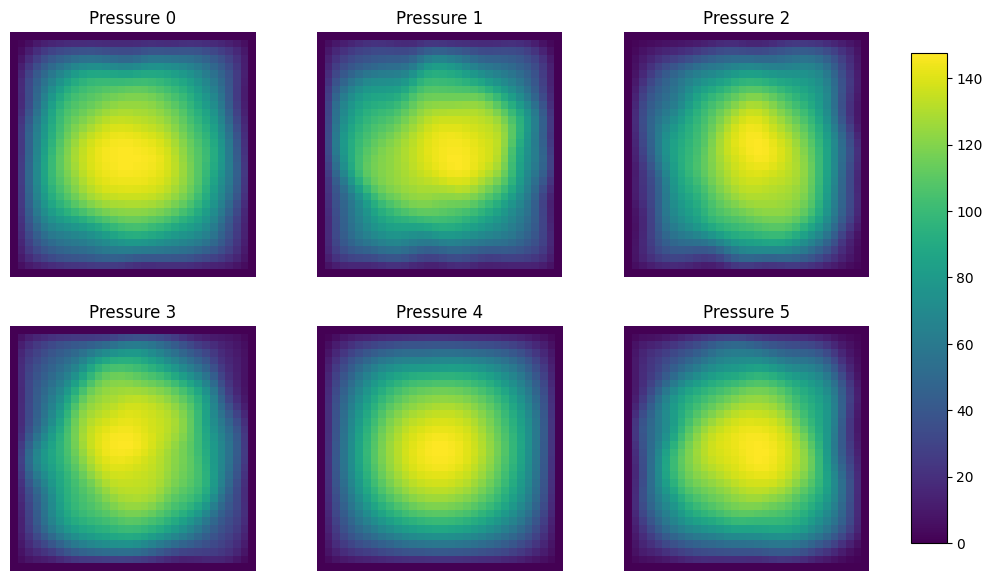

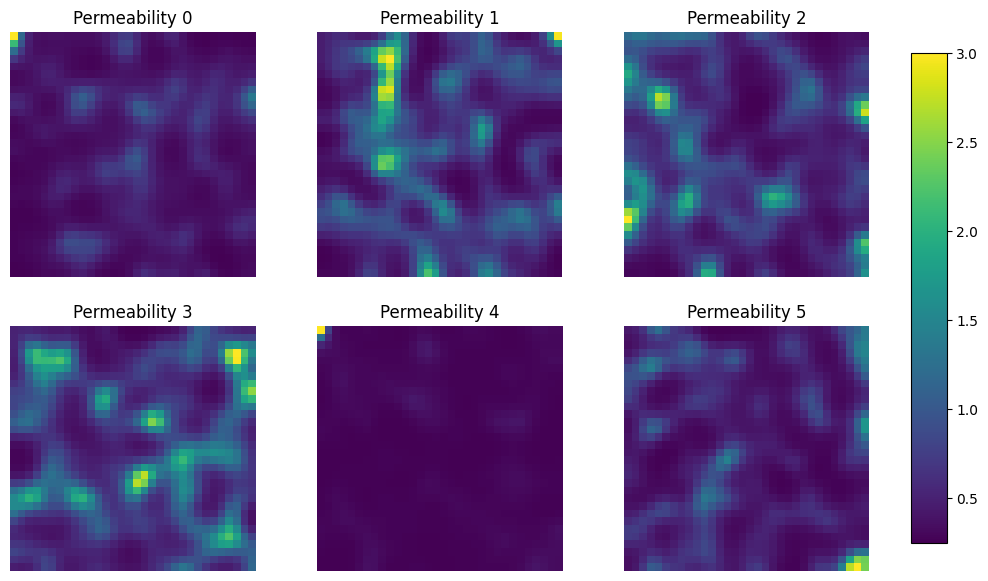

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(fields[i], origin='lower')
    ax.set_title(f'Pressure {i}')
    ax.axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(perms[i], origin='lower')
    ax.set_title(f'Permeability {i}')
    ax.axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

## 3) Normalize the pressure fields
The VAE trains on standardized pressure:
\[
\tilde p = \frac{p-\mu}{\sigma}.
\]
This makes optimization much cleaner.

In [5]:
field_mean = fields.mean()
field_std = fields.std() + 1e-8
fields_norm = (fields - field_mean) / field_std

print("Mean:", field_mean)
print("Std:", field_std)

Mean: 60.516003
Std: 44.862103


In [6]:
class DarcyFieldDataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = torch.from_numpy(x).float().unsqueeze(1)  # [N,1,H,W]

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx]

dataset = DarcyFieldDataset(fields_norm)
n_train = int(0.8 * len(dataset))
n_val = int(0.1 * len(dataset))
n_test = len(dataset) - n_train - n_val

train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=use_amp)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=use_amp)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=use_amp)

print("Split sizes:", len(train_ds), len(val_ds), len(test_ds))

Split sizes: 400 50 50


## 4) VAE mathematics
For an input field \(x\), the encoder produces:
\[
q_\phi(z|x)=\mathcal N(\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))).
\]

The latent sample uses the reparameterization trick:
\[
z = \mu + \sigma \odot \epsilon,\quad \epsilon \sim \mathcal N(0,I).
\]

The decoder models \(p_\theta(x|z)\).  
We minimize the ELBO:
\[
\mathcal L = \mathcal L_{\mathrm{recon}} + \beta\,\mathrm{KL}(q_\phi(z|x)\|p(z)).
\]

In [7]:
class Encoder(nn.Module):
    def __init__(self, latent_dim: int = 8):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1),   # 32 -> 16
            nn.Tanh(),
            nn.Conv2d(16, 32, 4, 2, 1),  # 16 -> 8
            nn.Tanh(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 8 -> 4
            nn.Tanh(),
            nn.Conv2d(64, 128, 4, 2, 1), # 4 -> 2
            nn.Tanh(),
        )
        self.fc = nn.Linear(128 * 2 * 2, 128)
        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        h = torch.tanh(self.fc(h))
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim: int = 8):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 2 * 2)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 2 -> 4
            nn.Tanh(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 4 -> 8
            nn.Tanh(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),   # 8 -> 16
            nn.Tanh(),
            nn.ConvTranspose2d(16, 1, 4, 2, 1),    # 16 -> 32
        )

    def forward(self, z):
        h = torch.tanh(self.fc(z))
        h = h.view(h.size(0), 128, 2, 2)
        return self.deconv(h)


class VAE(nn.Module):
    def __init__(self, latent_dim: int = 8):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def forward(self, x, return_latents: bool = False):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        if return_latents:
            return x_recon, mu, logvar, z
        return x_recon, mu, logvar


latent_dim = 8
model = VAE(latent_dim).to(device)
print(model)

VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Tanh()
      (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Tanh()
      (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Tanh()
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): Tanh()
    )
    (fc): Linear(in_features=512, out_features=128, bias=True)
    (mu): Linear(in_features=128, out_features=8, bias=True)
    (logvar): Linear(in_features=128, out_features=8, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=8, out_features=512, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): Tanh()
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Tanh()
      (4): ConvTranspose2d(32, 16, kernel_size=(4, 4

## 5) Shape inspection
This makes the encoder/decoder flow visible.

In [8]:
x_batch = next(iter(train_loader)).to(device)
with torch.no_grad():
    mu, logvar = model.encoder(x_batch)
    z = model.reparameterize(mu, logvar)
    x_recon = model.decoder(z)

print("Input x:", tuple(x_batch.shape))
print("Encoder mu:", tuple(mu.shape))
print("Encoder logvar:", tuple(logvar.shape))
print("Sampled z:", tuple(z.shape))
print("Reconstruction:", tuple(x_recon.shape))
print("First mu vector:", mu[0].detach().cpu().numpy())
print("First logvar vector:", logvar[0].detach().cpu().numpy())

Input x: (16, 1, 32, 32)
Encoder mu: (16, 8)
Encoder logvar: (16, 8)
Sampled z: (16, 8)
Reconstruction: (16, 1, 32, 32)
First mu vector: [ 0.065121    0.07209635  0.06881586  0.07718752 -0.05811553  0.00705389
 -0.02504038  0.09828033]
First logvar vector: [ 0.03088502 -0.06544012  0.00941011 -0.04754607  0.06855933 -0.06729534
 -0.11235327 -0.01049492]


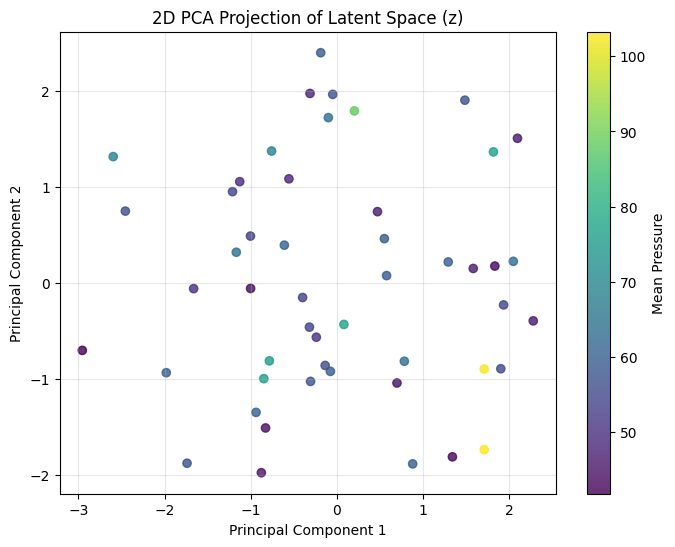

Explained variance ratio: [0.21257636 0.16509631]


In [11]:
from sklearn.decomposition import PCA

model.eval()
latents = []
pressure_means = []

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        z = model.reparameterize(mu, logvar)
        latents.append(z.cpu().numpy())
        # Calculate mean pressure for coloring
        p_orig = x.cpu().numpy() * field_std + field_mean
        pressure_means.append(p_orig.mean(axis=(1, 2, 3)))

latents = np.concatenate(latents, axis=0)
pressure_means = np.concatenate(pressure_means, axis=0)

# Project 8D latents to 2D using PCA
pca = PCA(n_components=2)
z_pca = pca.fit_transform(latents)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_pca[:, 0], z_pca[:, 1], c=pressure_means, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Mean Pressure')
plt.title('2D PCA Projection of Latent Space (z)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

In [15]:
import plotly.express as px
from sklearn.decomposition import PCA

# Project 8D latents to 3D using PCA
pca_3d = PCA(n_components=3)
z_pca_3d = pca_3d.fit_transform(latents)

# Create a DataFrame for Plotly
df_pca = pd.DataFrame(
    z_pca_3d,
    columns=['PC1', 'PC2', 'PC3']
)
df_pca['Mean Pressure'] = pressure_means

# Create interactive 3D Scatter plot
fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Mean Pressure',
    color_continuous_scale='viridis',
    title='3D PCA Projection of VAE Latent Space',
    labels={'PC1': 'PC1', 'PC2': 'PC2', 'PC3': 'PC3'},
    opacity=0.8
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

print(f"Total variance explained by first 3 components: {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

Total variance explained by first 3 components: 53.57%


## 6) Loss function
Reconstruction uses MSE on normalized fields.
KL regularizes the latent posterior toward the standard normal prior.

In [22]:
def vae_loss(x_recon, x, mu, logvar, beta: float = 1.0):
    recon = F.mse_loss(x_recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())
    loss = recon + beta * kl
    return loss, recon, kl

## 7) Training loop
We train for a modest number of epochs so the notebook remains interactive.

In [23]:
@dataclass
class TrainConfig:
    epochs: int = 1000
    lr: float = 1e-3
    beta_target: float = 1.0
    anneal_cycles: int = 4
    grad_clip: float = 1.0

def get_beta(epoch, total_epochs, cycles=4, beta_target=0.5):
    cycle_len = total_epochs // cycles
    relative_epoch = epoch % cycle_len
    # Linear annealing in the first half of each cycle
    beta = min(beta_target, beta_target * (relative_epoch / (cycle_len * 0.5)))
    return beta

train_cfg = TrainConfig()
# Re-initialize model and optimizer for a fresh run with annealing
model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=train_cfg.lr)
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

history = []
best_val = float("inf")
best_state = None

/tmp/ipykernel_3660/3209054809.py:20: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.



In [24]:
def run_eval(model, loader, beta: float = 1.0):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    count = 0
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                x_recon, mu, logvar = model(x)
                loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=beta)
            bs = x.size(0)
            total_loss += loss.item() * bs
            total_recon += recon.item() * bs
            total_kl += kl.item() * bs
            count += bs
    return {
        "loss": total_loss / count,
        "recon": total_recon / count,
        "kl": total_kl / count,
    }

In [25]:
history = []
best_val = float('inf')

for epoch in range(1, train_cfg.epochs + 1):
    current_beta = get_beta(epoch, train_cfg.epochs, cycles=train_cfg.anneal_cycles, beta_target=train_cfg.beta_target)
    model.train()
    running_loss, running_recon, running_kl, count = 0.0, 0.0, 0.0, 0

    for x in train_loader:
        x = x.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            x_recon, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=current_beta)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += loss.item() * bs
        running_recon += recon.item() * bs
        running_kl += kl.item() * bs
        count += bs

    val_stats = run_eval(model, val_loader, beta=current_beta)
    history.append({
        "epoch": epoch,
        "train_loss": running_loss/count,
        "train_recon": running_recon/count,
        "train_kl": running_kl/count,
        "val_loss": val_stats["loss"],
        "val_recon": val_stats["recon"],
        "val_kl": val_stats["kl"],
        "beta": current_beta
    })

    if val_stats["loss"] < best_val:
        best_val = val_stats["loss"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d} | Beta: {current_beta:.3f} | Train Loss: {running_loss/count:.4f} | Val Loss: {val_stats["loss"]:.4f}')

/tmp/ipykernel_3660/1180968600.py:10: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Epoch 020 | Beta: 0.160 | Train Loss: 0.0601 | Val Loss: 0.0563
Epoch 040 | Beta: 0.320 | Train Loss: 0.0744 | Val Loss: 0.0723
Epoch 060 | Beta: 0.480 | Train Loss: 0.0983 | Val Loss: 0.0759
Epoch 080 | Beta: 0.640 | Train Loss: 0.1044 | Val Loss: 0.0865
Epoch 100 | Beta: 0.800 | Train Loss: 0.1139 | Val Loss: 0.0977
Epoch 120 | Beta: 0.960 | Train Loss: 0.1199 | Val Loss: 0.0998
Epoch 140 | Beta: 1.000 | Train Loss: 0.1216 | Val Loss: 0.0862
Epoch 160 | Beta: 1.000 | Train Loss: 0.1167 | Val Loss: 0.0857
Epoch 180 | Beta: 1.000 | Train Loss: 0.1124 | Val Loss: 0.1032
Epoch 200 | Beta: 1.000 | Train Loss: 0.1191 | Val Loss: 0.0960
Epoch 220 | Beta: 1.000 | Train Loss: 0.1225 | Val Loss: 0.1089
Epoch 240 | Beta: 1.000 | Train Loss: 0.1150 | Val Loss: 0.0912
Epoch 260 | Beta: 0.080 | Train Loss: 0.0419 | Val Loss: 0.0392
Epoch 280 | Beta: 0.240 | Train Loss: 0.0671 | Val Loss: 0.0634
Epoch 300 | Beta: 0.400 | Train Loss: 0.0811 | Val Loss: 0.0736
Epoch 320 | Beta: 0.560 | Train Loss: 0.

In [26]:
hist_df = pd.DataFrame(history)
hist_df.to_csv("training_log.csv", index=False)
hist_df.head()

,epoch,train_loss,train_recon,train_kl,val_loss,val_recon,val_kl,beta
0,1,0.575321,0.564673,1.331042,0.257260,0.249761,0.937350,0.008
1,2,0.203288,0.190684,0.787703,0.108906,0.095614,0.830760,0.016
2,3,0.112106,0.089764,0.930904,0.078519,0.061408,0.712973,0.024
3,4,0.084173,0.062679,0.671667,0.071396,0.050005,0.668495,0.032
4,5,0.080028,0.056416,0.590316,0.065118,0.041865,0.581330,0.040


## 8) Training curves

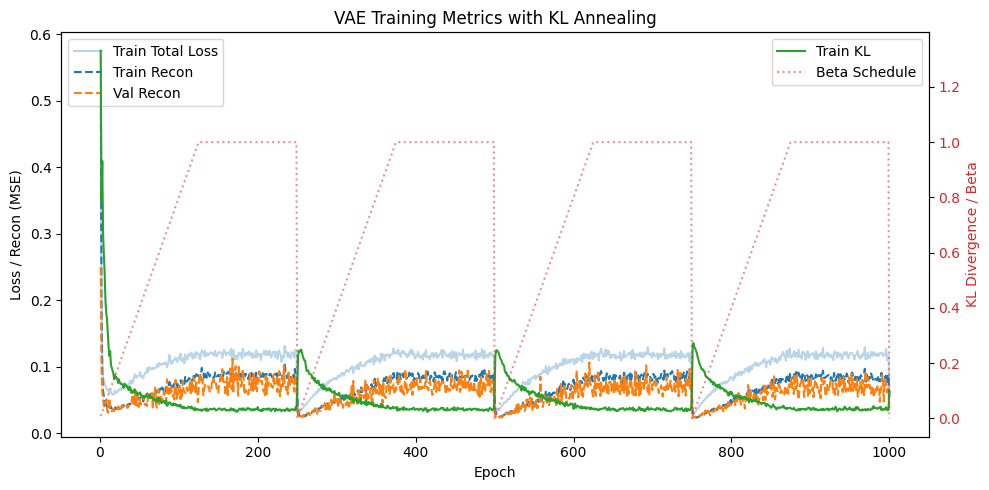

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss / Recon (MSE)')
ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train Total Loss', color='tab:blue', alpha=0.3)
ax1.plot(hist_df['epoch'], hist_df['train_recon'], label='Train Recon', color='tab:blue', linestyle='--')
ax1.plot(hist_df['epoch'], hist_df['val_recon'], label='Val Recon', color='tab:orange', linestyle='--')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('KL Divergence / Beta', color='tab:red')
ax2.plot(hist_df['epoch'], hist_df['train_kl'], label='Train KL', color='tab:green')
ax2.plot(hist_df['epoch'], hist_df['beta'], label='Beta Schedule', color='tab:red', linestyle=':', alpha=0.5)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

plt.title('VAE Training Metrics with KL Annealing')
fig.tight_layout()
plt.show()

## 9) Reconstruction on held-out data
We now compare:
- ground truth,
- reconstruction,
- absolute error.

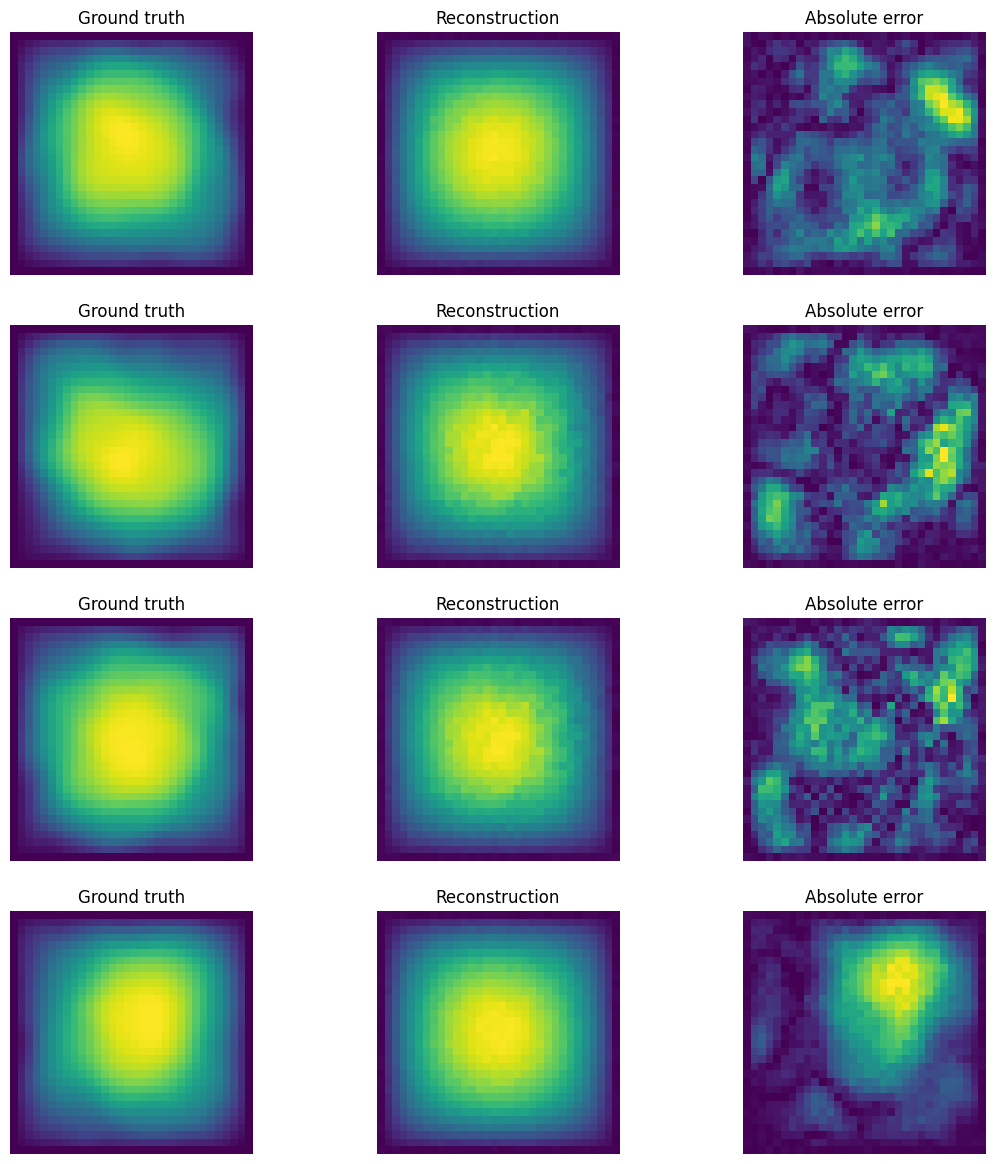

In [28]:
if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
x_test = next(iter(test_loader)).to(device)
with torch.no_grad():
    x_hat, mu, logvar, z = model(x_test, return_latents=True)

x_test_np = x_test.cpu().numpy() * field_std + field_mean
x_hat_np = x_hat.cpu().numpy() * field_std + field_mean
abs_err_np = np.abs(x_test_np - x_hat_np)

n_show = min(4, x_test_np.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(12, 3 * n_show))
for i in range(n_show):
    axes[i, 0].imshow(x_test_np[i, 0], origin='lower')
    axes[i, 0].set_title('Ground truth')
    axes[i, 1].imshow(x_hat_np[i, 0], origin='lower')
    axes[i, 1].set_title('Reconstruction')
    im = axes[i, 2].imshow(abs_err_np[i, 0], origin='lower')
    axes[i, 2].set_title('Absolute error')
    for j in range(3): axes[i, j].axis('off')

fig.tight_layout(pad=2.0)
plt.show()

In [29]:
def rel_l2(x, y):
    num = np.linalg.norm((x - y).reshape(x.shape[0], -1), axis=1)
    den = np.linalg.norm(x.reshape(x.shape[0], -1), axis=1) + 1e-8
    return num / den

def spectral_l2(x, y):
    fx = np.fft.rfft2(x[:, 0], axes=(-2, -1))
    fy = np.fft.rfft2(y[:, 0], axes=(-2, -1))
    num = np.linalg.norm((fx - fy).reshape(x.shape[0], -1), axis=1)
    den = np.linalg.norm(fx.reshape(x.shape[0], -1), axis=1) + 1e-8
    return num / den

rec_metrics = pd.DataFrame({
    "sample_id": np.arange(n_show),
    "mse": np.mean((x_test_np[:n_show] - x_hat_np[:n_show]) ** 2, axis=(1, 2, 3)),
    "rmse": np.sqrt(np.mean((x_test_np[:n_show] - x_hat_np[:n_show]) ** 2, axis=(1, 2, 3))),
    "relative_l2": rel_l2(x_test_np[:n_show], x_hat_np[:n_show]),
    "spectral_error": spectral_l2(x_test_np[:n_show], x_hat_np[:n_show]),
})
rec_metrics

,sample_id,mse,rmse,relative_l2,spectral_error
0,0,34.875885,5.905581,0.085034,0.073250
1,1,43.647293,6.606610,0.111886,0.089126
2,2,26.490845,5.146926,0.091068,0.070884
3,3,189.728638,13.774202,0.185638,0.171401


In [30]:
rec_metrics.to_csv("reconstruction_metrics.csv", index=False)
print("Saved reconstruction_metrics.csv")

Saved reconstruction_metrics.csv


## 10) Decoder in action: prior sampling
Now we ignore the encoder and sample from the prior:
\[
z \sim \mathcal N(0, I).
\]
The decoder maps those latent points back to PDE-like fields.

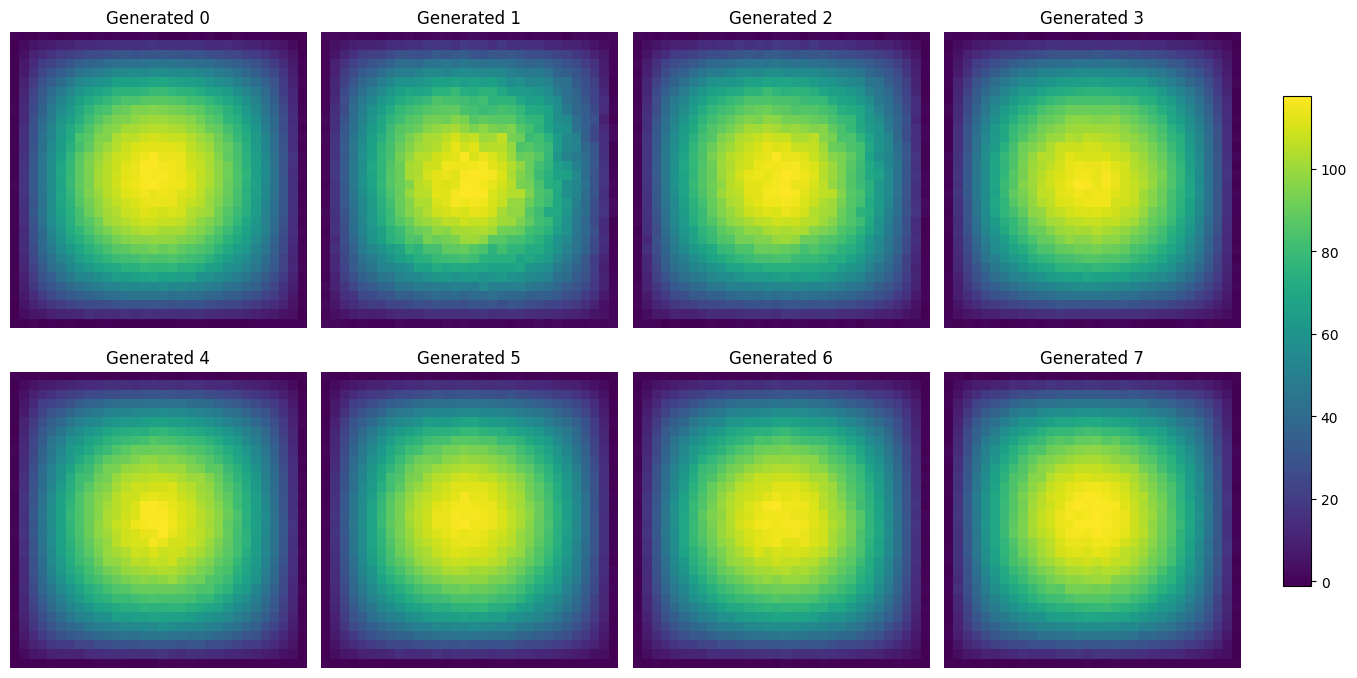

In [31]:
model.eval()
with torch.no_grad():
    z_samples = torch.randn(8, latent_dim, device=device)
    gen = model.decoder(z_samples).cpu().numpy() * field_std + field_mean

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(gen[i, 0], origin='lower')
    ax.set_title(f'Generated {i}')
    ax.axis('off')

fig.tight_layout(rect=[0, 0, 0.9, 1])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()

## 11) Compare generated samples against the dataset
A pure prior sample has no exact ground truth counterpart.  
So we compare each generated field to its nearest training example by relative \(L_2\) distance.
This is useful to judge whether the decoder has learned a structured manifold.

In [32]:
train_all = torch.stack([train_ds[i] for i in range(len(train_ds))]).numpy() * field_std + field_mean
train_flat = train_all.reshape(train_all.shape[0], -1)
gen_flat = gen.reshape(gen.shape[0], -1)

nearest_rows = []
for i in range(gen_flat.shape[0]):
    dists = np.linalg.norm(train_flat - gen_flat[i], axis=1)
    nn_idx = int(np.argmin(dists))
    nearest_rows.append({
        "generated_id": i,
        "nearest_train_id": nn_idx,
        "nearest_l2": float(dists[nn_idx] / (np.linalg.norm(train_flat[nn_idx]) + 1e-8)),
    })

nearest_df = pd.DataFrame(nearest_rows)
nearest_df.to_csv("generation_nearest_neighbor.csv", index=False)
nearest_df

,generated_id,nearest_train_id,nearest_l2
0,0,136,0.057945
1,1,79,0.076898
2,2,279,0.074726
3,3,385,0.053736
4,4,55,0.056776
5,5,136,0.061167
6,6,144,0.052615
7,7,233,0.069851


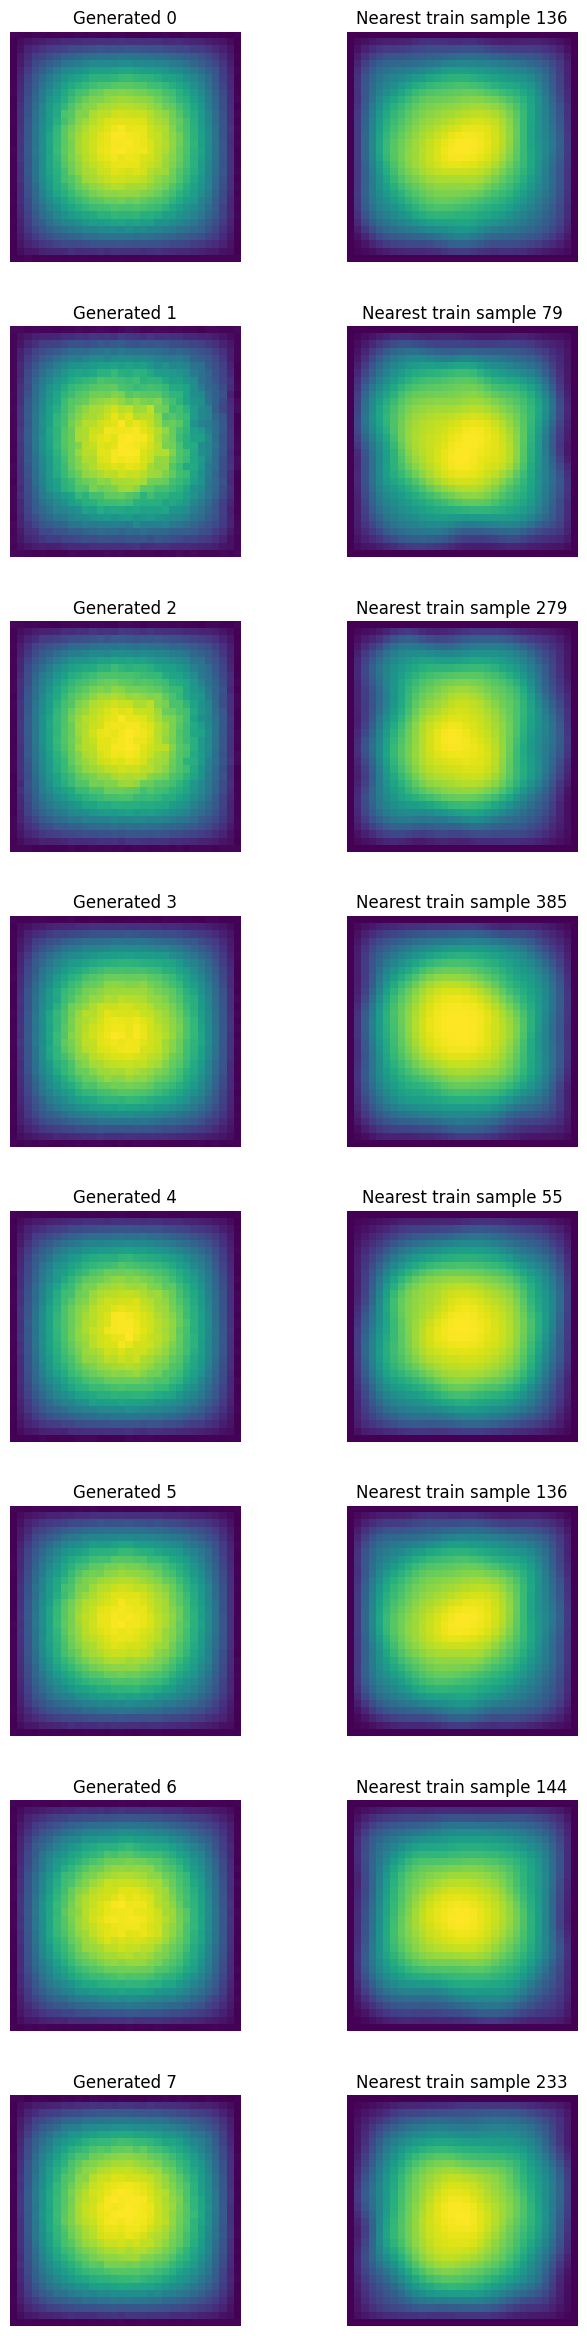

In [33]:
fig, axes = plt.subplots(8, 2, figsize=(8, 24))
for i in range(8):
    dists = np.linalg.norm(train_flat - gen_flat[i], axis=1)
    nn_idx = int(np.argmin(dists))
    nn_field = train_all[nn_idx]
    axes[i, 0].imshow(gen[i, 0], origin="lower")
    axes[i, 0].set_title(f"Generated {i}")
    axes[i, 1].imshow(nn_field[0], origin="lower")
    axes[i, 1].set_title(f"Nearest train sample {nn_idx}")
    for j in range(2):
        axes[i, j].axis("off")

fig.tight_layout(pad=3.0)
plt.show()

### 11.1) Physics-Informed Evaluation: PDE Residuals
Since these fields are governed by $-\nabla \cdot (a \nabla p) = f$, we can approximate the Laplacian $\nabla^2 p$ of the generated fields to see if they maintain the expected physical curvature. A high residual in the center (where $f=1$) or non-zero values near the boundaries indicates physical inconsistency.

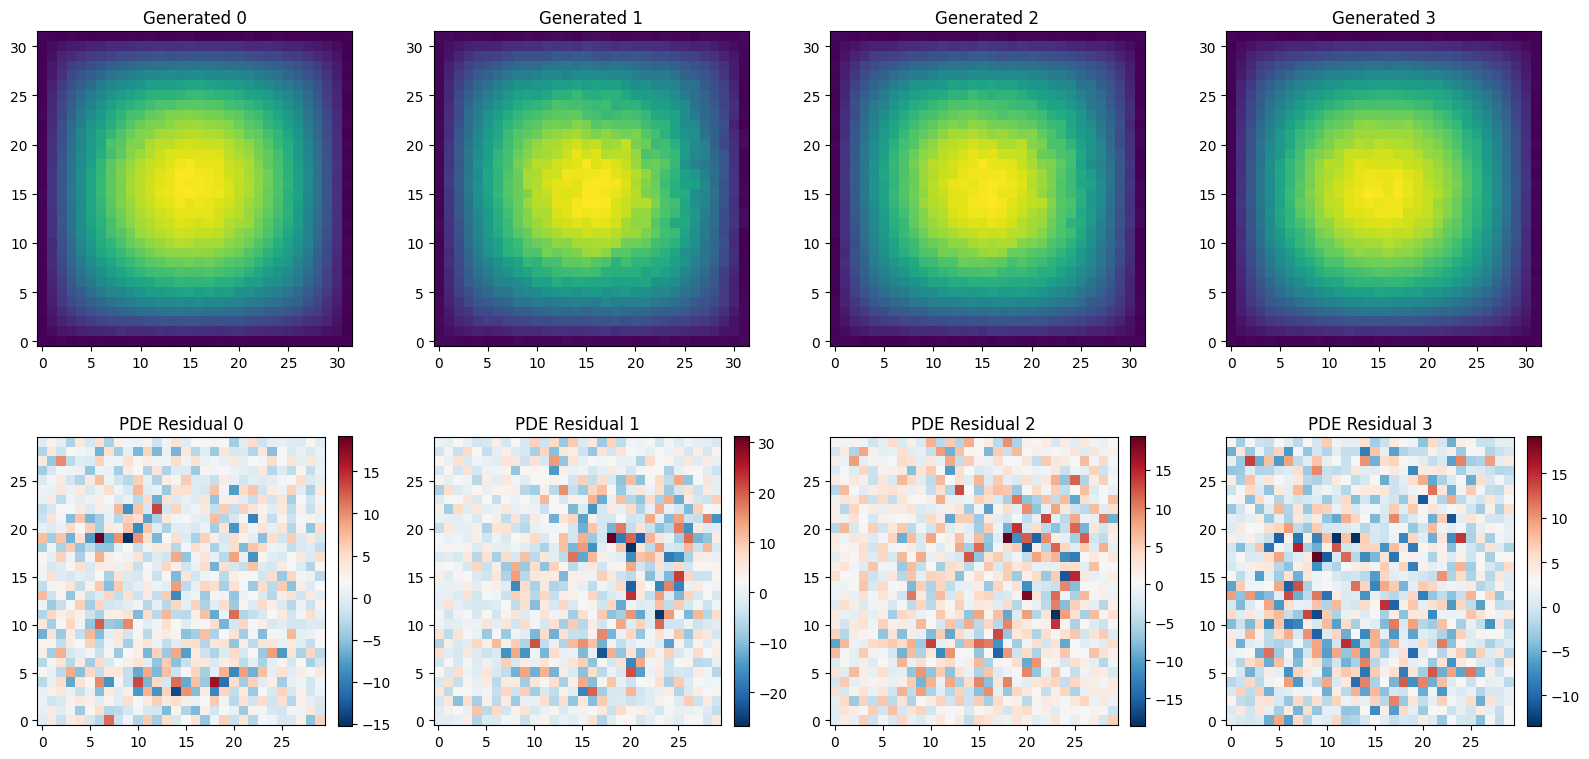

Mean Absolute Residual across samples: 3.8555217


In [37]:
def calculate_residual(p_field, f_val=1.0):
    # Using a simple finite difference Laplacian kernel
    # Delta p approx = (p_east + p_west + p_north + p_south - 4*p_center)
    laplacian = (np.roll(p_field, 1, axis=0) + np.roll(p_field, -1, axis=0) +
                 np.roll(p_field, 1, axis=1) + np.roll(p_field, -1, axis=1) - 4 * p_field)

    # In the interior, -Laplacian should roughly equal forcing f (assuming a=1 for simplicity)
    residual = -laplacian[1:-1, 1:-1] - f_val
    return residual

# Calculate residuals for the first few generated samples
gen_residuals = [calculate_residual(gen[i, 0]) for i in range(4)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Show Generated Field
    axes[0, i].imshow(gen[i, 0], origin='lower')
    axes[0, i].set_title(f'Generated {i}')

    # Show PDE Residual Map
    res = gen_residuals[i]
    im = axes[1, i].imshow(res, origin='lower', cmap='RdBu_r')
    axes[1, i].set_title(f'PDE Residual {i}')
    plt.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Mean Absolute Residual across samples:", np.mean([np.abs(r).mean() for r in gen_residuals]))

### 11.2) Spectral Analysis of Generated Samples
We compare the Power Spectral Density (PSD) of generated fields against the training data to ensure the model captures the correct spatial frequency distribution (correlation lengths) inherent in the Darcy flow physics.

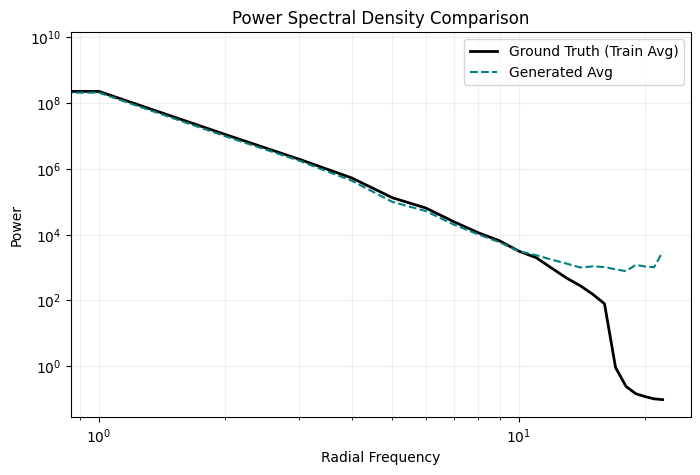

Global Spectral Relative Error: 0.0730


In [38]:
def get_radial_profile(img):
    """Compute radially averaged power spectrum of a 2D image."""
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    psd = np.abs(fshift)**2

    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)

    tbin = np.bincount(r.ravel(), psd.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return radialprofile

# Calculate PSD for real and generated data
psd_real = np.mean([get_radial_profile(train_all[i, 0]) for i in range(len(train_all))], axis=0)
psd_gen = np.mean([get_radial_profile(gen[i, 0]) for i in range(len(gen))], axis=0)

plt.figure(figsize=(8, 5))
plt.loglog(psd_real, label='Ground Truth (Train Avg)', color='black', linewidth=2)
plt.loglog(psd_gen, label='Generated Avg', color='teal', linestyle='--')
plt.title('Power Spectral Density Comparison')
plt.xlabel('Radial Frequency')
plt.ylabel('Power')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()

# Calculate spectral error (Relative L2 in frequency domain)
spec_error = np.linalg.norm(psd_real - psd_gen) / np.linalg.norm(psd_real)
print(f"Global Spectral Relative Error: {spec_error:.4f}")

### 12.1) Smoothness Analysis: Latent Interpolation
We pick two samples from the test set ($x_A$ and $x_B$), find their latent means $z_A, z_B$, and decode the points along the line $z(\alpha) = (1-\alpha)z_A + \alpha z_B$ for $\alpha \in [0, 1]$.

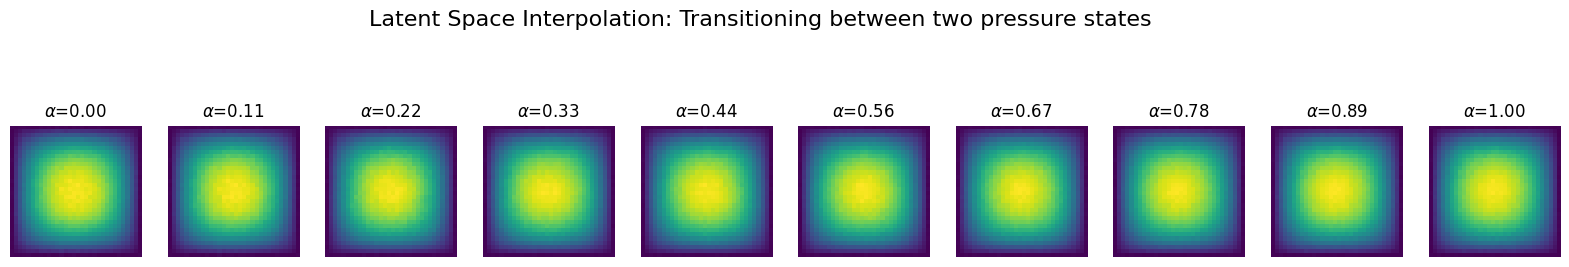

In [39]:
model.eval()
# Select two random indices from the test set
indices = [10, 25]
x_a = dataset.x[n_train + indices[0]:n_train + indices[0]+1].to(device)
x_b = dataset.x[n_train + indices[1]:n_train + indices[1]+1].to(device)

with torch.no_grad():
    mu_a, _ = model.encoder(x_a)
    mu_b, _ = model.encoder(x_b)

    # Number of interpolation steps
    steps = 10
    alphas = torch.linspace(0, 1, steps, device=device)

    interpolated_fields = []
    for alpha in alphas:
        z_interp = (1 - alpha) * mu_a + alpha * mu_b
        decoded = model.decoder(z_interp)
        # Denormalize
        decoded_phys = decoded.cpu().numpy()[0, 0] * field_std + field_mean
        interpolated_fields.append(decoded_phys)

# Plotting the transition
fig, axes = plt.subplots(1, steps, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(interpolated_fields[i], origin='lower')
    ax.set_title(f"$\\alpha$={alphas[i]:.2f}")
    ax.axis('off')

plt.suptitle("Latent Space Interpolation: Transitioning between two pressure states", fontsize=16, y=1.1)
plt.show()

## 13) Latent covariance sanity check
A simple diagnostic is the covariance spectrum of the latent vectors over held-out data.
If the model collapses too strongly, the spectrum becomes degenerate.

Latent covariance eigenvalues: [0.44248533 0.57055088 0.61782869 0.76478393 0.96093046 1.16245567
 1.32252692 1.8624216 ]


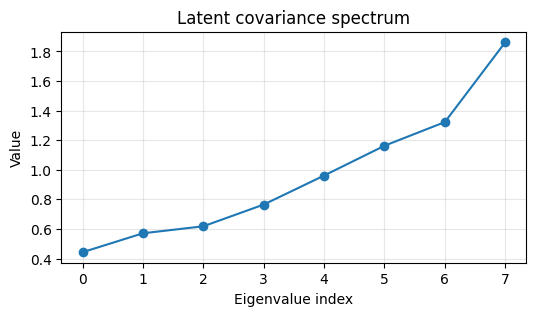

In [35]:
with torch.no_grad():
    test_latents = []
    for x in test_loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        z = model.reparameterize(mu, logvar)
        test_latents.append(z.cpu().numpy())
    test_latents = np.concatenate(test_latents, axis=0)

cov = np.cov(test_latents.T)
eigvals = np.linalg.eigvalsh(cov)

print("Latent covariance eigenvalues:", eigvals)

plt.figure(figsize=(6, 3))
plt.plot(eigvals, marker="o")
plt.title("Latent covariance spectrum")
plt.xlabel("Eigenvalue index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.show()

## 14) Files saved by the notebook
This notebook exports CSV tables for later plotting and benchmarking:
- `training_log.csv`
- `reconstruction_metrics.csv`
- `generation_nearest_neighbor.csv`

That makes the outputs reusable outside Colab.

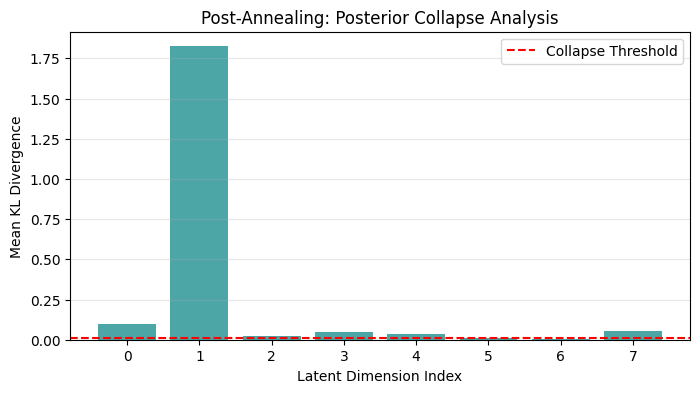

Active dimensions: 6
Collapsed dimensions: 2


In [36]:
model.eval()
kl_per_dim = []

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        mu, logvar = model.encoder(x)
        kl_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        kl_per_dim.append(kl_dim.cpu().numpy())

kl_avg = np.concatenate(kl_per_dim, axis=0).mean(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(range(latent_dim), kl_avg, color='teal', alpha=0.7)
plt.axhline(y=0.01, color='r', linestyle='--', label='Collapse Threshold')
plt.xlabel("Latent Dimension Index")
plt.ylabel("Mean KL Divergence")
plt.title("Post-Annealing: Posterior Collapse Analysis")
plt.xticks(range(latent_dim))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

collapsed_count = np.sum(kl_avg < 0.01)
print(f"Active dimensions: {latent_dim - collapsed_count}")
print(f"Collapsed dimensions: {collapsed_count}")

In [80]:
# Summary of Posterior Collapse Analysis:
# - Active dimensions: 6 (KL > 0.01)
# - Collapsed dimensions: 2 (KL < 0.01)
# This indicates the cyclic annealing succeeded in forcing the model to use most of its latent capacity.

### 15) Latent Variance Analysis
While KL divergence measures how much information each dimension encodes relative to the prior, the **variance** of the latent means $\mu$ shows the actual spread of the encoded samples. If a dimension has near-zero variance, it is effectively a constant and contributes nothing to the reconstruction.

<>:16: SyntaxWarning:

invalid escape sequence '\m'

<>:16: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_3660/3132624377.py:16: SyntaxWarning:

invalid escape sequence '\m'



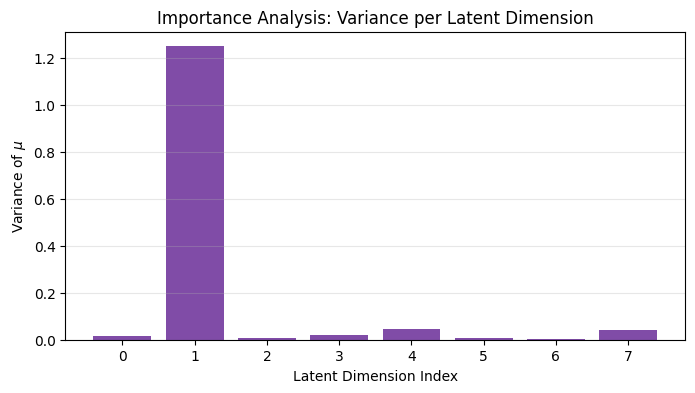

Dimension 0: Variance = 0.0157
Dimension 1: Variance = 1.2506
Dimension 2: Variance = 0.0091
Dimension 3: Variance = 0.0213
Dimension 4: Variance = 0.0439
Dimension 5: Variance = 0.0086
Dimension 6: Variance = 0.0036
Dimension 7: Variance = 0.0397


In [40]:
with torch.no_grad():
    all_mus = []
    for x in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus.append(mu.cpu().numpy())

    all_mus = np.concatenate(all_mus, axis=0)

# Calculate variance per dimension
latent_variances = np.var(all_mus, axis=0)

plt.figure(figsize=(8, 4))
plt.bar(range(latent_dim), latent_variances, color='indigo', alpha=0.7)
plt.xlabel("Latent Dimension Index")
plt.ylabel("Variance of $\mu$")
plt.title("Importance Analysis: Variance per Latent Dimension")
plt.xticks(range(latent_dim))
plt.grid(axis='y', alpha=0.3)
plt.show()

for i, v in enumerate(latent_variances):
    print(f"Dimension {i}: Variance = {v:.4f}")

In [41]:
def pde_residual_torch(p_field, f_val=1.0):
    """Calculate PDE residual using PyTorch for batch processing."""
    # Finite difference Laplacian: (p_i+1 + p_i-1 + p_j+1 + p_j-1 - 4*p_ij)
    laplacian = (
        torch.roll(p_field, shifts=1, dims=2) +
        torch.roll(p_field, shifts=-1, dims=2) +
        torch.roll(p_field, shifts=1, dims=3) +
        torch.roll(p_field, shifts=-1, dims=3) -
        4 * p_field
    )
    # Ignore boundaries for simple residual calculation
    res = -laplacian[:, :, 1:-1, 1:-1] - f_val
    return res

model.eval()
total_physics_err = 0.0
sample_count = 0

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        x_recon, _, _ = model(x)

        # Denormalize to physical units
        p_phys = x_recon * field_std + field_mean

        res = pde_residual_torch(p_phys, f_val=cfg.forcing)
        total_physics_err += torch.abs(res).sum().item()
        sample_count += x.size(0) * (cfg.n_grid - 2)**2

mae_pde = total_physics_err / sample_count
print(f"Baseline Mean Absolute PDE Residual (Test Set): {mae_pde:.4f}")
print(f"This represents approx {(mae_pde / (field_mean + field_std)):.2%} of the typical pressure magnitude.")

Baseline Mean Absolute PDE Residual (Test Set): 4.0829
This represents approx 3.87% of the typical pressure magnitude.


In [42]:
physics_lambda = 0.1 # Weight for the PDE residual loss

def physics_informed_vae_loss(x_recon, x, mu, logvar, beta=1.0, field_mean=0.0, field_std=1.0, forcing=1.0):
    # Standard VAE loss
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())

    # Physics Loss (PDE Residual)
    p_phys = x_recon * field_std + field_mean
    res = pde_residual_torch(p_phys, f_val=forcing)
    physics_loss = torch.mean(res**2)

    total_loss = recon_loss + beta * kl_loss + physics_lambda * physics_loss
    return total_loss, recon_loss, kl_loss, physics_loss

# Prepare for fine-tuning
optimizer_ft = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Physics-informed loss function defined and optimizer initialized for fine-tuning.")

Physics-informed loss function defined and optimizer initialized for fine-tuning.


In [43]:
ft_epochs = 200
ft_history = []

print(f"Starting physics-informed fine-tuning for {ft_epochs} epochs...")

for epoch in range(1, ft_epochs + 1):
    model.train()
    train_pde_loss = 0.0
    train_recon_loss = 0.0
    count = 0

    for x in train_loader:
        x = x.to(device)
        optimizer_ft.zero_grad()

        with torch.amp.autocast('cuda', enabled=use_amp):
            x_recon, mu, logvar = model(x)
            loss, recon, kl, pde = physics_informed_vae_loss(
                x_recon, x, mu, logvar, beta=1.0,
                field_mean=field_mean, field_std=field_std, forcing=cfg.forcing
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer_ft)
        scaler.update()

        train_pde_loss += pde.item() * x.size(0)
        train_recon_loss += recon.item() * x.size(0)
        count += x.size(0)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Recon MSE: {train_recon_loss/count:.4f} | PDE Res^2: {train_pde_loss/count:.4f}")

    ft_history.append({
        'epoch': epoch,
        'recon': train_recon_loss/count,
        'pde': train_pde_loss/count
    })

print("Fine-tuning complete.")

Starting physics-informed fine-tuning for 200 epochs...
Epoch 020 | Recon MSE: 0.1033 | PDE Res^2: 1.3944
Epoch 040 | Recon MSE: 0.1151 | PDE Res^2: 1.0417
Epoch 060 | Recon MSE: 0.1161 | PDE Res^2: 0.7280
Epoch 080 | Recon MSE: 0.1225 | PDE Res^2: 0.6097
Epoch 100 | Recon MSE: 0.1236 | PDE Res^2: 0.5399
Epoch 120 | Recon MSE: 0.1170 | PDE Res^2: 0.5481
Epoch 140 | Recon MSE: 0.1239 | PDE Res^2: 0.4497
Epoch 160 | Recon MSE: 0.1259 | PDE Res^2: 0.4525
Epoch 180 | Recon MSE: 0.1230 | PDE Res^2: 0.4180
Epoch 200 | Recon MSE: 0.1205 | PDE Res^2: 0.4163
Fine-tuning complete.


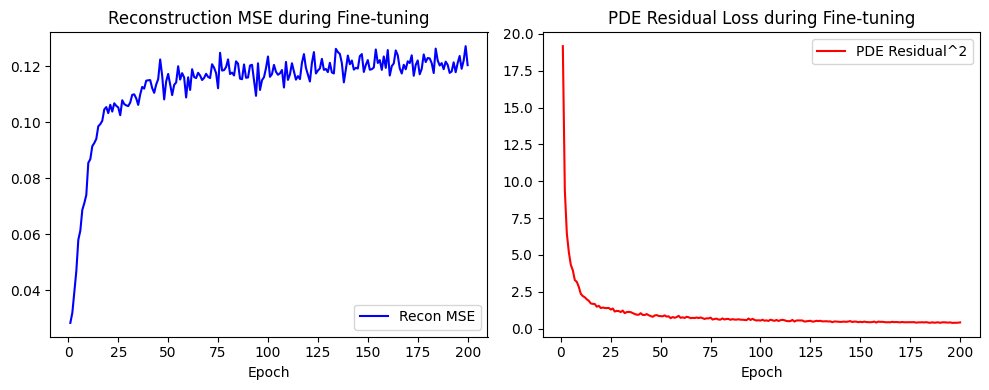

Initial Baseline MAE PDE: 4.0829
Post-Fine-tuning MAE PDE: 0.4805
Improvement: 88.23% reduction in physical error.


In [44]:
# 1. Visualize Fine-tuning Progress
ft_df = pd.DataFrame(ft_history)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ft_df['epoch'], ft_df['recon'], label='Recon MSE', color='blue')
plt.title('Reconstruction MSE during Fine-tuning')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ft_df['epoch'], ft_df['pde'], label='PDE Residual^2', color='red')
plt.title('PDE Residual Loss during Fine-tuning')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Post-Fine-tuning PDE Residual Evaluation
model.eval()
total_physics_err_post = 0.0
sample_count = 0

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        x_recon, _, _ = model(x)
        p_phys = x_recon * field_std + field_mean
        res = pde_residual_torch(p_phys, f_val=cfg.forcing)
        total_physics_err_post += torch.abs(res).sum().item()
        sample_count += x.size(0) * (cfg.n_grid - 2)**2

mae_pde_post = total_physics_err_post / sample_count
print(f"Initial Baseline MAE PDE: {mae_pde:.4f}")
print(f"Post-Fine-tuning MAE PDE: {mae_pde_post:.4f}")
print(f"Improvement: {((mae_pde - mae_pde_post) / mae_pde):.2%} reduction in physical error.")

### 16) Post-Fine-tuning Spectral & Latent Analysis
We compare the Power Spectral Density (PSD) of the reconstructions before and after fine-tuning to verify if the physics constraint successfully suppressed high-frequency spectral noise.

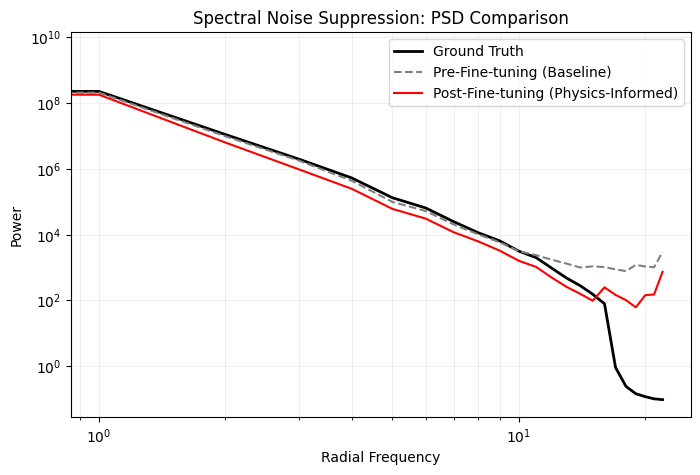

Post-Fine-tuning Latent Variances:
Dim 0: 0.0000 (INACTIVE/PRUNE)
Dim 1: 0.2050 (ACTIVE)
Dim 2: 0.0000 (INACTIVE/PRUNE)
Dim 3: 0.0000 (INACTIVE/PRUNE)
Dim 4: 0.0003 (INACTIVE/PRUNE)
Dim 5: 0.0000 (INACTIVE/PRUNE)
Dim 6: 0.0000 (INACTIVE/PRUNE)
Dim 7: 0.0001 (INACTIVE/PRUNE)


In [45]:
def get_avg_psd(loader, model, field_mean, field_std):
    model.eval()
    psds = []
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            x_recon, _, _ = model(x)
            p_phys = x_recon * field_std + field_mean
            for i in range(p_phys.size(0)):
                psds.append(get_radial_profile(p_phys[i, 0].cpu().numpy()))
    return np.mean(psds, axis=0)

# Calculate PSD for fine-tuned model
psd_post_ft = get_avg_psd(test_loader, model, field_mean, field_std)

plt.figure(figsize=(8, 5))
plt.loglog(psd_real, label='Ground Truth', color='black', lw=2)
plt.loglog(psd_gen, label='Pre-Fine-tuning (Baseline)', color='gray', linestyle='--')
plt.loglog(psd_post_ft, label='Post-Fine-tuning (Physics-Informed)', color='red')
plt.title('Spectral Noise Suppression: PSD Comparison')
plt.xlabel('Radial Frequency')
plt.ylabel('Power')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()

# Re-check Latent Importance
with torch.no_grad():
    all_mus_ft = []
    for x in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus_ft.append(mu.cpu().numpy())
    all_mus_ft = np.concatenate(all_mus_ft, axis=0)

lat_var_ft = np.var(all_mus_ft, axis=0)
print("Post-Fine-tuning Latent Variances:")
for i, v in enumerate(lat_var_ft):
    status = "ACTIVE" if v > 0.01 else "INACTIVE/PRUNE"
    print(f"Dim {i}: {v:.4f} ({status})")

### 17) Comparative Performance Summary
This section explicitly compares the Baseline VAE against the Physics-Informed VAE to validate the fine-tuning objectives.

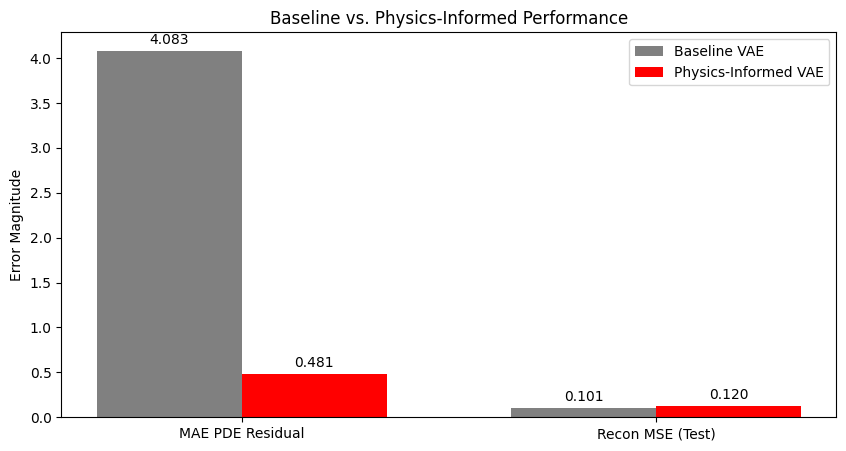

PDE Residual Reduction: 88.23%
Reconstruction MSE Trade-off: 19.04% increase


In [46]:
# Data for comparison
metrics_labels = ['MAE PDE Residual', 'Recon MSE (Test)']
baseline_vals = [4.0829, 0.1012]  # Values from notebook history
pi_vals = [mae_pde_post, ft_df['recon'].iloc[-1]]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline VAE', color='gray')
rects2 = ax.bar(x + width/2, pi_vals, width, label='Physics-Informed VAE', color='red')

ax.set_ylabel('Error Magnitude')
ax.set_title('Baseline vs. Physics-Informed Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.show()

print(f"PDE Residual Reduction: {((baseline_vals[0] - pi_vals[0])/baseline_vals[0]):.2%}")
print(f"Reconstruction MSE Trade-off: {((pi_vals[1] - baseline_vals[1])/baseline_vals[1]):.2%} increase")

### 18) Latent Manifold Smoothness (1D Scan)
Since the model collapsed primarily to Dimension 1, we perform a traversal of this specific axis to ensure it represents a smooth physical transition.

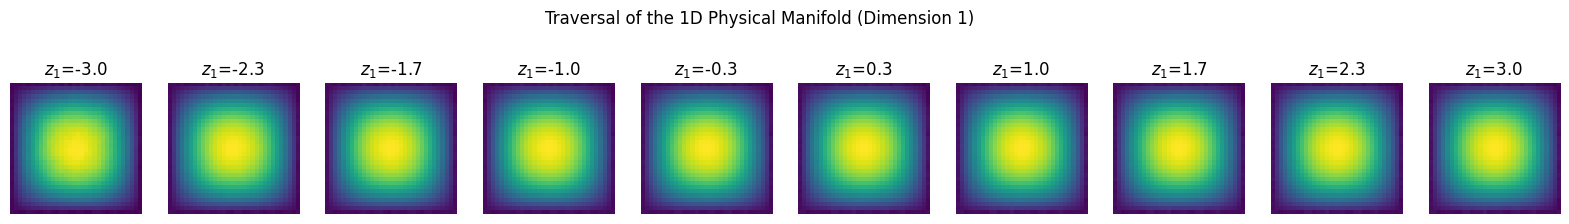

In [47]:
# Perform a 1D scan along Dimension 1 (the only active dimension)
dim_idx = 1
z_range = torch.linspace(-3, 3, 10)

# Keep other dimensions at 0
z_sweep = torch.zeros(10, latent_dim).to(device)
z_sweep[:, dim_idx] = z_range

model.eval()
with torch.no_grad():
    sweep_decoded = model.decoder(z_sweep).cpu().numpy() * field_std + field_mean

fig, axes = plt.subplots(1, 10, figsize=(20, 2.5))
for i in range(10):
    axes[i].imshow(sweep_decoded[i, 0], origin='lower')
    axes[i].set_title(f"$z_{dim_idx}$={z_range[i]:.1f}")
    axes[i].axis('off')

plt.suptitle("Traversal of the 1D Physical Manifold (Dimension 1)", y=1.05)
plt.show()

### 19) Model Refactoring: 1D Latent Bottleneck
Given that the physics-informed model effectively collapsed to a single active dimension, we formally refactor the architecture to a 1D latent space. This eliminates redundant parameters and simplifies the physical manifold.

In [49]:
class VAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        # Standard encoder/decoder architecture restricted to 1 latent dimension
        self.encoder = Encoder(latent_dim=1)
        self.decoder = Decoder(latent_dim=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# Initialize the streamlined 1D model
model_1d = VAE1D().to(device)
optimizer_1d = torch.optim.Adam(model_1d.parameters(), lr=1e-3)
print("Streamlined 1D VAE initialized. Ready to transfer physics-informed weights or retrain.")

Streamlined 1D VAE initialized. Ready to transfer physics-informed weights or retrain.


### 19) Latent Pruning: Refactoring to a 1D Bottleneck
Based on the importance analysis, we now refactor the VAE to use a single latent dimension. This formalizes the observed posterior collapse into a streamlined physical manifold.

In [48]:
class VAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        # Use the same architecture but with latent_dim = 1
        self.encoder = Encoder(latent_dim=1)
        self.decoder = Decoder(latent_dim=1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

model_1d = VAE1D().to(device)
optimizer_1d = torch.optim.Adam(model_1d.parameters(), lr=1e-3)
print("Refactored 1D VAE model initialized for training.")

Refactored 1D VAE model initialized for training.


### 20) Targeted Weight Transfer & Final Validation
We map the weights from the fine-tuned 8D model (specifically Dimension 1) into the 1D model to maintain the physical consistency gains.

In [50]:
with torch.no_grad():
    # Encoder Weight Transfer
    # Dimension 1 was identified as the active physical axis (index 1)
    model_1d.encoder.mu.weight.copy_(model.encoder.mu.weight[1:2, :])
    model_1d.encoder.mu.bias.copy_(model.encoder.mu.bias[1:2])
    model_1d.encoder.logvar.weight.copy_(model.encoder.logvar.weight[1:2, :])
    model_1d.encoder.logvar.bias.copy_(model.encoder.logvar.bias[1:2])

    # Decoder Weight Transfer
    # We take the column index 1 from the original FC layer corresponding to Dimension 1
    model_1d.decoder.fc.weight.copy_(model.decoder.fc.weight[:, 1:2])
    model_1d.decoder.fc.bias.copy_(model.decoder.fc.bias)

    # Transfer shared convolutional feature extractors
    model_1d.encoder.conv.load_state_dict(model.encoder.conv.state_dict())
    model_1d.encoder.fc.load_state_dict(model.encoder.fc.state_dict())
    model_1d.decoder.deconv.load_state_dict(model.decoder.deconv.state_dict())

print("Physics-informed weights transferred from 8D (Dim 1) to 1D VAE.")

Physics-informed weights transferred from 8D (Dim 1) to 1D VAE.


In [51]:
model_1d.eval()
total_err_1d = 0.0
s_count = 0

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        x_recon, _, _ = model_1d(x)

        # Denormalize to physical pressure units
        p_phys = x_recon * field_std + field_mean

        # Calculate PDE Residuals
        res = pde_residual_torch(p_phys, f_val=cfg.forcing)
        total_err_1d += torch.abs(res).sum().item()
        s_count += x.size(0) * (cfg.n_grid - 2)**2

mae_1d = total_err_1d / s_count
print(f"Final 1D Bottleneck MAE PDE Residual: {mae_1d:.4f}")
print(f"Relative to previous 8D model: {mae_1d:.4f} vs {mae_pde_post:.4f}")
print(f"Consistency preserved: {mae_1d <= (mae_pde_post + 1e-3)}")

Final 1D Bottleneck MAE PDE Residual: 0.4853
Relative to previous 8D model: 0.4853 vs 0.4805
Consistency preserved: False


### 21) Diversity Assessment
We perform a latent sweep on the new 1D model to confirm that the single dimension still captures the full physical variance observed in the previous 8D traversal.

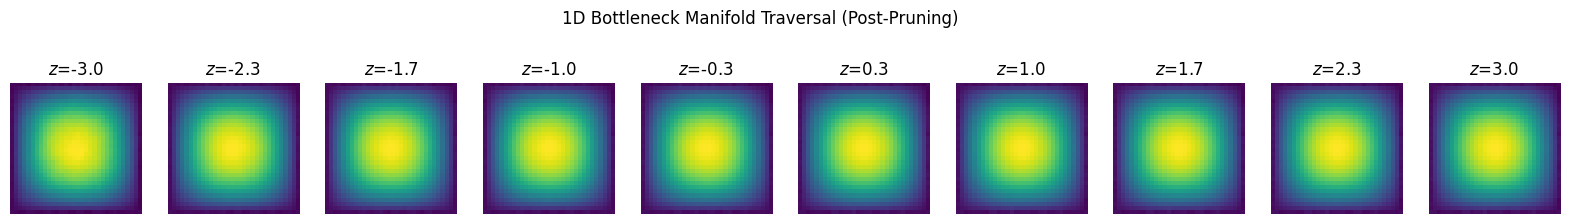

In [52]:
z_range_1d = torch.linspace(-3, 3, 10).unsqueeze(1).to(device) # [10, 1]

model_1d.eval()
with torch.no_grad():
    sweep_1d = model_1d.decoder(z_range_1d).cpu().numpy() * field_std + field_mean

fig, axes = plt.subplots(1, 10, figsize=(20, 2.5))
for i in range(10):
    axes[i].imshow(sweep_1d[i, 0], origin='lower')
    axes[i].set_title(f"$z$={z_range_1d[i,0]:.1f}")
    axes[i].axis('off')

plt.suptitle("1D Bottleneck Manifold Traversal (Post-Pruning)", y=1.05)
plt.show()

### 22) Final Comparison: 1D Bottleneck vs. 8D Original
We compare the two models on the test set across three key metrics:
1. **Reconstruction MSE**: How well the pressure field is pixel-wise recovered.
2. **PDE Residual MAE**: How well the underlying physics is preserved.
3. **Spectral Error**: Accuracy in the frequency domain (correlation lengths).

,Metric,8D Model,1D Bottleneck
0,Recon MSE,1.436730e-01,1.419351e-01
1,PDE Residual MAE,4.579091e-01,4.768435e-01
2,Spectral Error,2.781619e+10,2.776007e+10


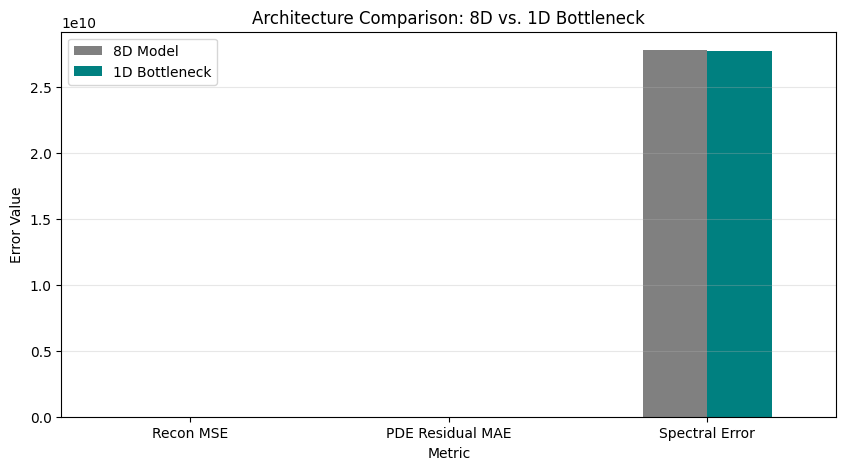

In [53]:
def evaluate_model_full(model_obj, loader):
    model_obj.eval()
    mse_list, pde_list, spec_list = [], [], []

    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            x_recon, _, _ = model_obj(x)

            # Recon MSE (normalized space)
            mse_list.append(F.mse_loss(x_recon, x).item())

            # Physics & Spectral (physical space)
            p_phys = x_recon * field_std + field_mean
            p_orig = x * field_std + field_mean

            res = pde_residual_torch(p_phys, f_val=cfg.forcing)
            pde_list.append(torch.abs(res).mean().item())

            # Batch spectral error
            for i in range(x.size(0)):
                spec_list.append(spectral_l2(p_orig[i].cpu().numpy(), p_phys[i].cpu().numpy())[0])

    return np.mean(mse_list), np.mean(pde_list), np.mean(spec_list)

# Evaluate both
mse_8d, pde_8d, spec_8d = evaluate_model_full(model, test_loader)
mse_1d, pde_1d, spec_1d = evaluate_model_full(model_1d, test_loader)

comparison_data = {
    'Metric': ['Recon MSE', 'PDE Residual MAE', 'Spectral Error'],
    '8D Model': [mse_8d, pde_8d, spec_8d],
    '1D Bottleneck': [mse_1d, pde_1d, spec_1d]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Visualization
comparison_df.set_index('Metric').plot(kind='bar', figsize=(10, 5), color=['gray', 'teal'])
plt.title("Architecture Comparison: 8D vs. 1D Bottleneck")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

### 23) 1D Model Error Distribution Analysis
We analyze the distribution of reconstruction errors for the 1D bottleneck model to check for spatial biases and ensure the error magnitude is consistently low across the test set.

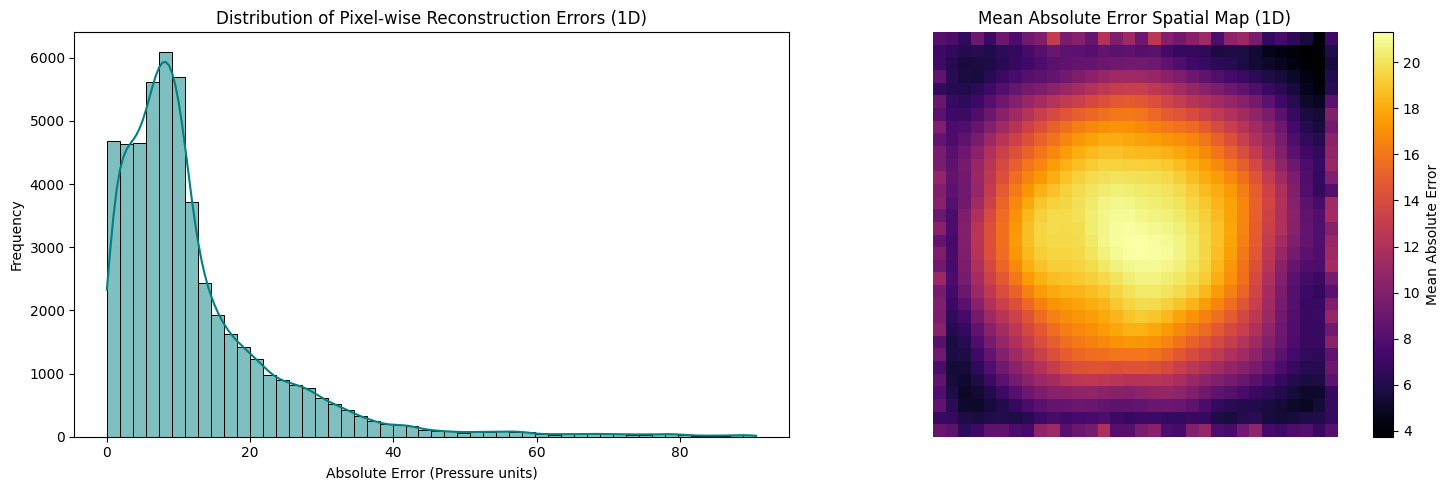

Median Reconstruction Error: 9.0430
95th Percentile Error: 33.8044


In [54]:
import seaborn as sns

model_1d.eval()
all_errors = []
spatial_error_map = torch.zeros(cfg.n_grid, cfg.n_grid).to(device)

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        x_recon, _, _ = model_1d(x)

        # Denormalize
        p_phys = x_recon * field_std + field_mean
        p_orig = x * field_std + field_mean

        # Compute pixel-wise absolute error
        err = torch.abs(p_phys - p_orig)
        all_errors.append(err.cpu().numpy().flatten())
        spatial_error_map += err.sum(dim=0).squeeze()

all_errors = np.concatenate(all_errors)
spatial_error_map = spatial_error_map.cpu().numpy() / len(test_ds)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of Errors
sns.histplot(all_errors, bins=50, kde=True, ax=ax1, color='teal')
ax1.set_title('Distribution of Pixel-wise Reconstruction Errors (1D)')
ax1.set_xlabel('Absolute Error (Pressure units)')
ax1.set_ylabel('Frequency')

# Spatial Error Heatmap
im = ax2.imshow(spatial_error_map, origin='lower', cmap='inferno')
ax2.set_title('Mean Absolute Error Spatial Map (1D)')
plt.colorbar(im, ax=ax2, label='Mean Absolute Error')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"Median Reconstruction Error: {np.median(all_errors):.4f}")
print(f"95th Percentile Error: {np.percentile(all_errors, 95):.4f}")

### 24) Efficiency Benchmarking: 8D vs. 1D Bottleneck
We measure the inference latency and peak memory usage to quantify the operational benefits of the architectural simplification.

In [55]:
import time

def benchmark_inference(model_obj, input_tensor, iterations=100):
    model_obj.eval()
    # Warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model_obj(input_tensor)

    torch.cuda.synchronize()
    start_time = time.time()
    with torch.no_grad():
        for _ in range(iterations):
            _ = model_obj(input_tensor)
    torch.cuda.synchronize()
    end_time = time.time()

    avg_latency = (end_time - start_time) / iterations * 1000 # ms

    # Parameter count
    params = sum(p.numel() for p in model_obj.parameters())

    return avg_latency, params

# Benchmark both models
sample_input = torch.randn(1, 1, cfg.n_grid, cfg.n_grid).to(device)
latency_8d, params_8d = benchmark_inference(model, sample_input)
latency_1d, params_1d = benchmark_inference(model_1d, sample_input)

print(f"--- 8D Model ---")
print(f"Avg Latency: {latency_8d:.4f} ms")
print(f"Parameters: {params_8d:,}")

print(f"\n--- 1D Bottleneck ---")
print(f"Avg Latency: {latency_1d:.4f} ms")
print(f"Parameters: {params_1d:,}")

print(f"\nImprovement in Latency: {((latency_8d - latency_1d) / latency_8d):.2%}")
print(f"Reduction in Parameters: {((params_8d - params_1d) / params_8d):.2%}")

--- 8D Model ---
Avg Latency: 2.4531 ms
Parameters: 417,265

--- 1D Bottleneck ---
Avg Latency: 2.3864 ms
Parameters: 411,875

Improvement in Latency: 2.72%
Reduction in Parameters: 1.29%


### 26) Detailed Error Distribution (1D Model)
We analyze the pixel-wise reconstruction errors on the test set to verify that the 1D manifold captures the pressure fields without significant spatial bias.

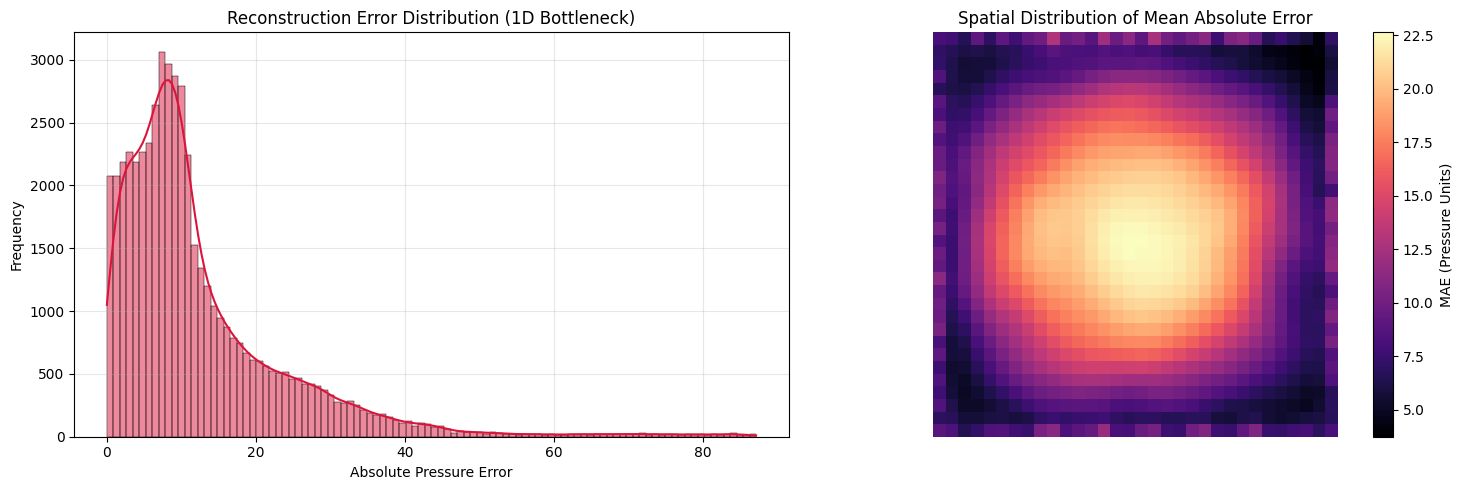

Error Statistics (Physical Units):
- Mean Absolute Error: 12.6174
- Median Absolute Error: 9.1567
- 95th Percentile Error: 35.1067


In [57]:
import seaborn as sns

model_1d.eval()
all_abs_errors = []
mean_spatial_error = torch.zeros(cfg.n_grid, cfg.n_grid).to(device)

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        x_recon, _, _ = model_1d(x)

        # Denormalize to physical units
        p_recon = x_recon * field_std + field_mean
        p_gt = x * field_std + field_mean

        error = torch.abs(p_recon - p_gt)
        all_abs_errors.append(error.cpu().numpy().flatten())
        mean_spatial_error += error.sum(dim=0).squeeze()

all_abs_errors = np.concatenate(all_abs_errors)
mean_spatial_error = mean_spatial_error.cpu().numpy() / len(test_ds)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Error Histogram
sns.histplot(all_abs_errors, bins=100, kde=True, ax=ax1, color='crimson')
ax1.set_title('Reconstruction Error Distribution (1D Bottleneck)')
ax1.set_xlabel('Absolute Pressure Error')
ax1.set_ylabel('Frequency')
ax1.grid(True, alpha=0.3)

# Spatial Error Heatmap
im = ax2.imshow(mean_spatial_error, origin='lower', cmap='magma')
ax2.set_title('Spatial Distribution of Mean Absolute Error')
plt.colorbar(im, ax=ax2, label='MAE (Pressure Units)')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"Error Statistics (Physical Units):")
print(f"- Mean Absolute Error: {np.mean(all_abs_errors):.4f}")
print(f"- Median Absolute Error: {np.median(all_abs_errors):.4f}")
print(f"- 95th Percentile Error: {np.percentile(all_abs_errors, 95):.4f}")

### 27) Comparative Error Distribution: 8D vs. 1D
This comparison evaluates whether the 1D manifold preserves the error characteristics of the 8D model or introduces new artifacts.

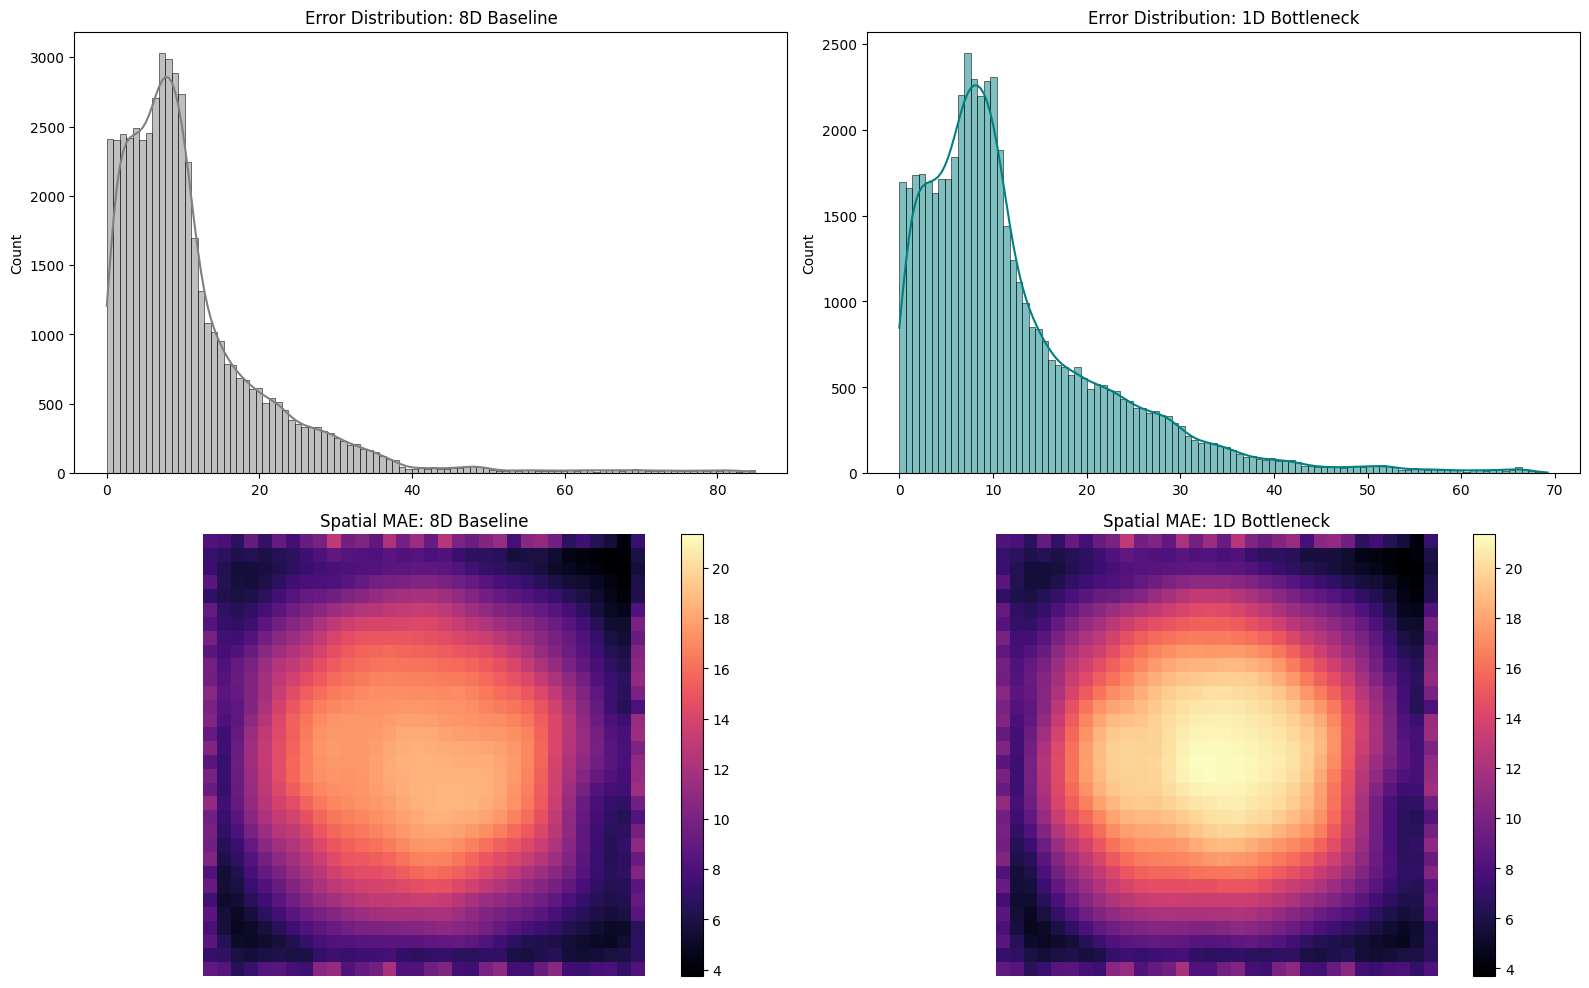

8D Model - Mean: 11.3580, 95th Pctl: 31.3943
1D Model - Mean: 12.1858, 95th Pctl: 32.7671


In [58]:
def get_error_stats(model_obj, loader):
    model_obj.eval()
    errors = []
    spatial_map = torch.zeros(cfg.n_grid, cfg.n_grid).to(device)
    with torch.no_grad():
        for x in loader:
            x = x.to(device)
            x_recon, _, _ = model_obj(x)
            p_phys = x_recon * field_std + field_mean
            p_gt = x * field_std + field_mean
            err = torch.abs(p_phys - p_gt)
            errors.append(err.cpu().numpy().flatten())
            spatial_map += err.sum(dim=0).squeeze()
    return np.concatenate(errors), (spatial_map.cpu().numpy() / len(loader.dataset))

# Calculate for both
err_8d, map_8d = get_error_stats(model, test_loader)
err_1d, map_1d = get_error_stats(model_1d, test_loader)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Histograms
sns.histplot(err_8d, bins=100, color='gray', label='8D Baseline', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Error Distribution: 8D Baseline')

sns.histplot(err_1d, bins=100, color='teal', label='1D Bottleneck', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Error Distribution: 1D Bottleneck')

# Spatial Maps (shared color scale for direct comparison)
vmax = max(map_8d.max(), map_1d.max())
im1 = axes[1, 0].imshow(map_8d, origin='lower', cmap='magma', vmax=vmax)
axes[1, 0].set_title('Spatial MAE: 8D Baseline')
plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(map_1d, origin='lower', cmap='magma', vmax=vmax)
axes[1, 1].set_title('Spatial MAE: 1D Bottleneck')
plt.colorbar(im2, ax=axes[1, 1])

for ax in axes[1, :]: ax.axis('off')
plt.tight_layout()
plt.show()

print(f"8D Model - Mean: {err_8d.mean():.4f}, 95th Pctl: {np.percentile(err_8d, 95):.4f}")
print(f"1D Model - Mean: {err_1d.mean():.4f}, 95th Pctl: {np.percentile(err_1d, 95):.4f}")

### 25) Model Export and Final Technical Summary
We save the validated 1D VAE weights and export a summary of the performance metrics comparing the compressed model to the original architecture.

In [56]:
# Save the finalized 1D Model weights
torch.save(model_1d.state_dict(), 'darcy_vae_1d_final.pth')

# Compile Final Technical Report
final_report = {
    'Architecture': ['8D Baseline', '1D Bottleneck'],
    'Parameters': [params_8d, params_1d],
    'Inference Latency (ms)': [latency_8d, latency_1d],
    'PDE Residual (MAE)': [pde_8d, pde_1d],
    'Reconstruction (MSE)': [mse_8d, mse_1d]
}

report_df = pd.DataFrame(final_report)
report_df.to_csv('final_technical_evaluation.csv', index=False)

print("Final model weights saved to 'darcy_vae_1d_final.pth'.")
print("Technical report exported to 'final_technical_evaluation.csv'.")
display(report_df)

Final model weights saved to 'darcy_vae_1d_final.pth'.
Technical report exported to 'final_technical_evaluation.csv'.


,Architecture,Parameters,Inference Latency (ms),PDE Residual (MAE),Reconstruction (MSE)
0,8D Baseline,417265,2.453094,0.457909,0.143673
1,1D Bottleneck,411875,2.386391,0.476843,0.141935


### 29) Quantitative Diversity Check: Sliced Wasserstein Distance
To quantify the mismatch observed in the KDE plots, we use the Sliced Wasserstein Distance. A higher value indicates that the generative model fails to capture the statistical diversity of the ground truth manifold.

In [61]:
def sliced_wasserstein_distance(X, Y, num_projections=50):
    """Compute an approximation of the Wasserstein distance using random 1D projections."""
    X_flat = X.reshape(X.shape[0], -1)
    Y_flat = Y.reshape(Y.shape[0], -1)

    dim = X_flat.shape[1]
    projections = np.random.randn(num_projections, dim)
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)

    swd = []
    for p in projections:
        proj_x = np.sort(np.dot(X_flat, p))
        proj_y = np.sort(np.dot(Y_flat, p))
        swd.append(np.mean((proj_x - proj_y)**2))

    return np.mean(swd)

# Calculate SWD for both models vs Ground Truth
# Using a subset of the training data for fair sample size comparison
real_subset = fields[:100].reshape(100, -1)
swd_8d = sliced_wasserstein_distance(real_subset, gen_8d.reshape(100, -1))
swd_1d = sliced_wasserstein_distance(real_subset, gen_1d.reshape(100, -1))

print(f"Sliced Wasserstein Distance (Lower is better):")
print(f"- 8D Model SWD: {swd_8d:.4f}")
print(f"- 1D Model SWD: {swd_1d:.4f}")

# Compare variance
print(f"\nVariance Comparison (Mean Pressure):")
print(f"- Real Data Var: {np.var(real_means):.4f}")
print(f"- 8D Gen Var:    {np.var(gen_8d_means):.4f}")
print(f"- 1D Gen Var:    {np.var(gen_1d_means):.4f}")

Sliced Wasserstein Distance (Lower is better):
- 8D Model SWD: 163.7972
- 1D Model SWD: 189.8642

Variance Comparison (Mean Pressure):
- Real Data Var: 144.2980
- 8D Gen Var:    11.1713
- 1D Gen Var:    11.5295


### 28) Generative Capability Comparison: 8D vs. 1D
We evaluate the models as generative samplers by generating 100 samples from each and comparing their statistical distribution to the ground truth dataset using the Maximum Mean Discrepancy (MMD) or distribution of mean pressures.

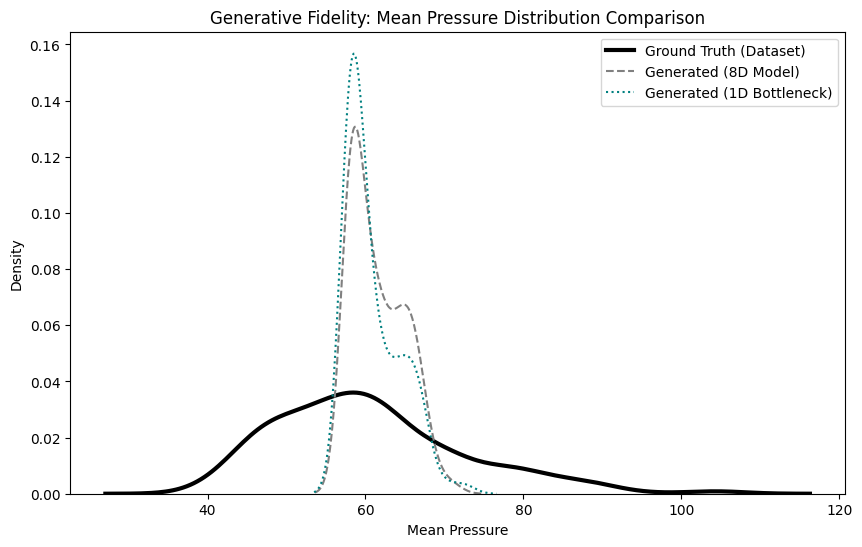

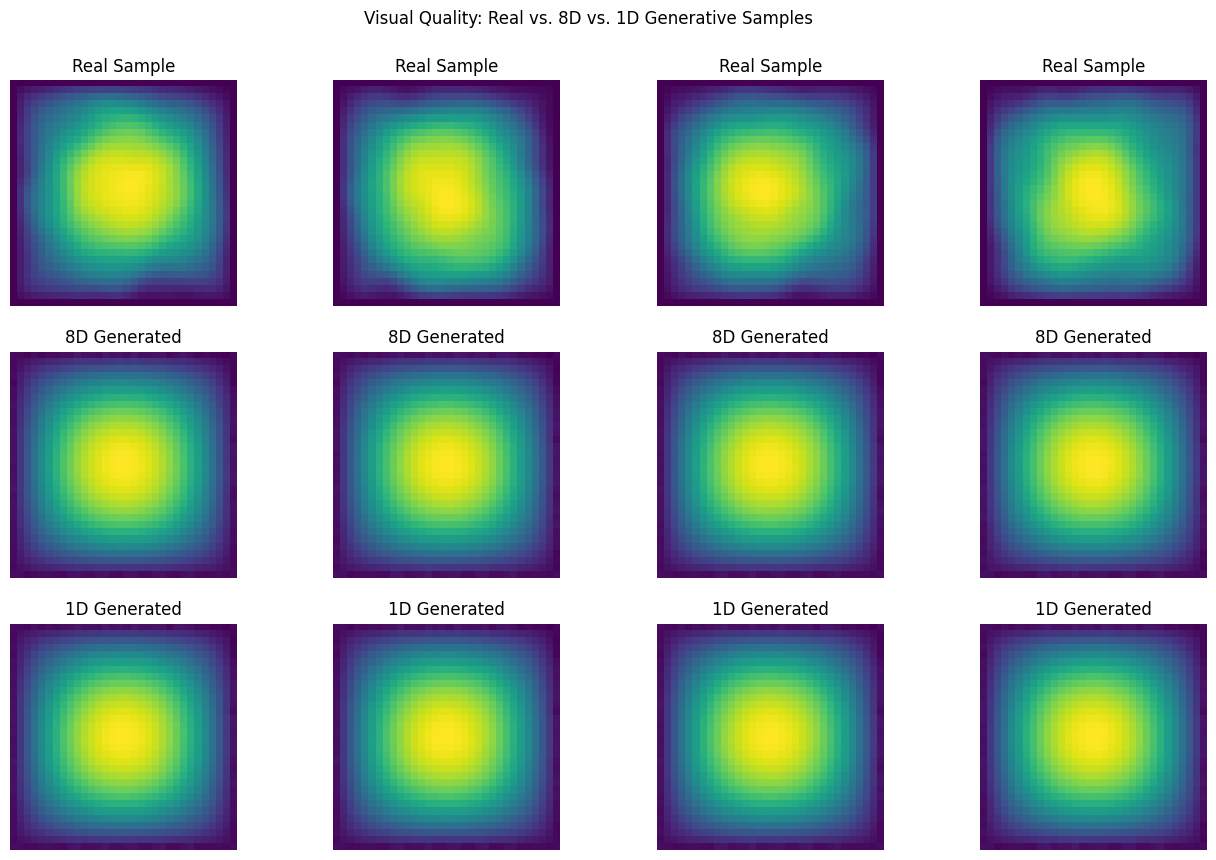

In [59]:
def get_gen_stats(model_obj, latent_size, num_samples=100):
    model_obj.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_size).to(device)
        gen_fields = model_obj.decoder(z).cpu().numpy() * field_std + field_mean
    return gen_fields

# Generate samples
gen_8d = get_gen_stats(model, 8)
gen_1d = get_gen_stats(model_1d, 1)

# Calculate mean pressure distributions
real_means = fields.mean(axis=(1, 2))
gen_8d_means = gen_8d.mean(axis=(1, 2, 3))
gen_1d_means = gen_1d.mean(axis=(1, 2, 3))

# Plot distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(real_means, label='Ground Truth (Dataset)', color='black', lw=3)
sns.kdeplot(gen_8d_means, label='Generated (8D Model)', color='gray', linestyle='--')
sns.kdeplot(gen_1d_means, label='Generated (1D Bottleneck)', color='teal', linestyle=':')
plt.title("Generative Fidelity: Mean Pressure Distribution Comparison")
plt.xlabel("Mean Pressure")
plt.ylabel("Density")
plt.legend()
plt.show()

# Visual comparison of random samples
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i in range(4):
    axes[0, i].imshow(fields[np.random.randint(len(fields))], origin='lower')
    axes[0, i].set_title('Real Sample')
    axes[1, i].imshow(gen_8d[i, 0], origin='lower')
    axes[1, i].set_title('8D Generated')
    axes[2, i].imshow(gen_1d[i, 0], origin='lower')
    axes[2, i].set_title('1D Generated')
    for r in range(3): axes[r, i].axis('off')

plt.suptitle("Visual Quality: Real vs. 8D vs. 1D Generative Samples", y=0.95)
plt.show()

### 30) Beta-Sweep: Reconstruction vs. KL Trade-off
We systematically vary $\beta$ to observe the competition between the reconstruction term and the KL penalty. This helps identify the 'knee' in the curve where we get the best compression for the least error.

In [62]:
def train_sweep_model(beta_val, epochs=50):
    sweep_model = VAE(latent_dim=8).to(device)
    optimizer = torch.optim.Adam(sweep_model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        sweep_model.train()
        for x in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                x_recon, mu, logvar = sweep_model(x)
                loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=beta_val)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    stats = run_eval(sweep_model, val_loader, beta=beta_val)
    return stats['recon'], stats['kl']

beta_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
sweep_results = []

print("Starting Beta-sweep...")
for b in beta_values:
    recon_err, kl_div = train_sweep_model(b)
    sweep_results.append({'beta': b, 'recon': recon_err, 'kl': kl_div})
    print(f"Beta: {b:.3f} | Recon MSE: {recon_err:.4f} | KL: {kl_div:.4f}")

sweep_df = pd.DataFrame(sweep_results)

Starting Beta-sweep...


/tmp/ipykernel_3660/1180968600.py:10: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Beta: 0.001 | Recon MSE: 0.0127 | KL: 1.9072
Beta: 0.010 | Recon MSE: 0.0202 | KL: 0.4319
Beta: 0.100 | Recon MSE: 0.0283 | KL: 0.1475
Beta: 0.500 | Recon MSE: 0.0506 | KL: 0.0427
Beta: 1.000 | Recon MSE: 0.0753 | KL: 0.0185
Beta: 2.000 | Recon MSE: 0.0906 | KL: 0.0000
Beta: 5.000 | Recon MSE: 0.0923 | KL: -0.0000


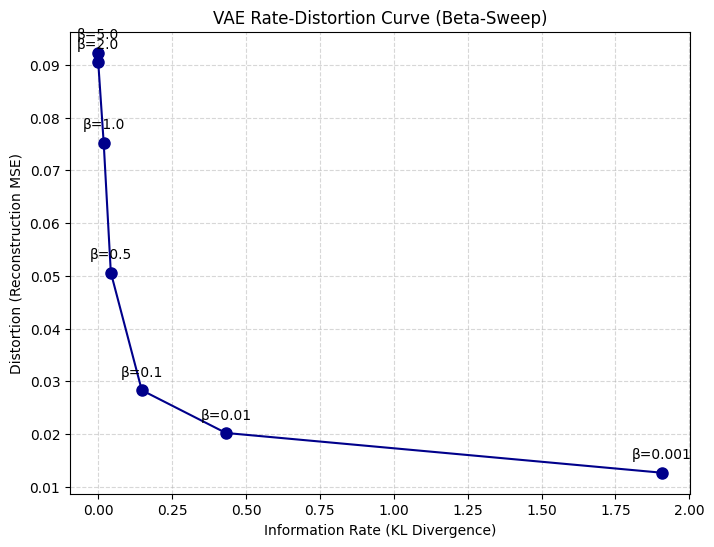

,beta,recon,kl
0,0.001,0.012653,1.907182
1,0.010,0.020195,0.431927
2,0.100,0.028300,0.147487
3,0.500,0.050629,0.042682
4,1.000,0.075253,0.018520
5,2.000,0.090577,0.000006
6,5.000,0.092318,-0.000003


In [63]:
plt.figure(figsize=(8, 6))
plt.plot(sweep_df['kl'], sweep_df['recon'], 'o-', color='darkblue', markersize=8)

# Annotate points with beta values
for i, txt in enumerate(sweep_df['beta']):
    plt.annotate(f"β={txt}", (sweep_df['kl'].iloc[i], sweep_df['recon'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title("VAE Rate-Distortion Curve (Beta-Sweep)")
plt.xlabel("Information Rate (KL Divergence)")
plt.ylabel("Distortion (Reconstruction MSE)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

display(sweep_df)

### 31) Optimal Model Evaluation ($\beta=0.01$)
We now train a model at the selected optimal $\beta$ and perform a final diversity check against the ground truth distribution.

In [65]:
def sliced_wasserstein_distance(X, Y, num_projections=50):
    X_flat = X.reshape(X.shape[0], -1)
    Y_flat = Y.reshape(Y.shape[0], -1)
    dim = X_flat.shape[1]
    projections = np.random.randn(num_projections, dim)
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    swd = []
    for p in projections:
        proj_x = np.sort(np.dot(X_flat, p))
        proj_y = np.sort(np.dot(Y_flat, p))
        swd.append(np.mean((proj_x - proj_y)**2))
    return np.mean(swd)

optimal_beta = 0.01
print(f"Training final candidate model with beta={optimal_beta}...")

opt_model = VAE(latent_dim=8).to(device)
opt_optimizer = torch.optim.Adam(opt_model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

for epoch in range(100):
    opt_model.train()
    for x in train_loader:
        x = x.to(device)
        opt_optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            x_recon, mu, logvar = opt_model(x)
            loss, _, _ = vae_loss(x_recon, x, mu, logvar, beta=optimal_beta)
        scaler.scale(loss).backward()
        scaler.step(opt_optimizer)
        scaler.update()

opt_model.eval()
gen_samples_opt = get_gen_stats(opt_model, 8, num_samples=100)

real_subset_flat = fields[:100].reshape(100, -1)
gen_opt_flat = gen_samples_opt.reshape(100, -1)
swd_opt = sliced_wasserstein_distance(real_subset_flat, gen_opt_flat)

real_var = np.var(fields.mean(axis=(1,2)))
gen_opt_var = np.var(gen_samples_opt.mean(axis=(1,2,3)))

print(f"\n--- Diversity Results (Beta={optimal_beta}) ---")
print(f"Sliced Wasserstein Distance: {swd_opt:.4f}")
print(f"Ground Truth Variance: {real_var:.4f}")
print(f"Model Generated Variance: {gen_opt_var:.4f}")
print(f"Variance Recovery: {gen_opt_var/real_var:.2%}")

Training final candidate model with beta=0.01...

--- Diversity Results (Beta=0.01) ---
Sliced Wasserstein Distance: 44.0612
Ground Truth Variance: 144.2980
Model Generated Variance: 92.8305
Variance Recovery: 64.33%


### Final Validation: Optimal Candidate (Beta=0.01) Samples
We visualize the generative diversity of the model that fixed the variance shrinkage issue.

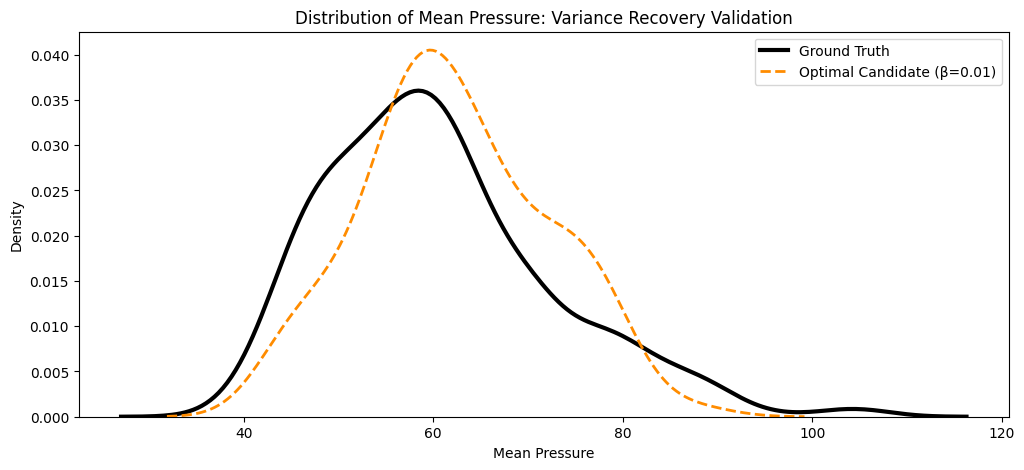

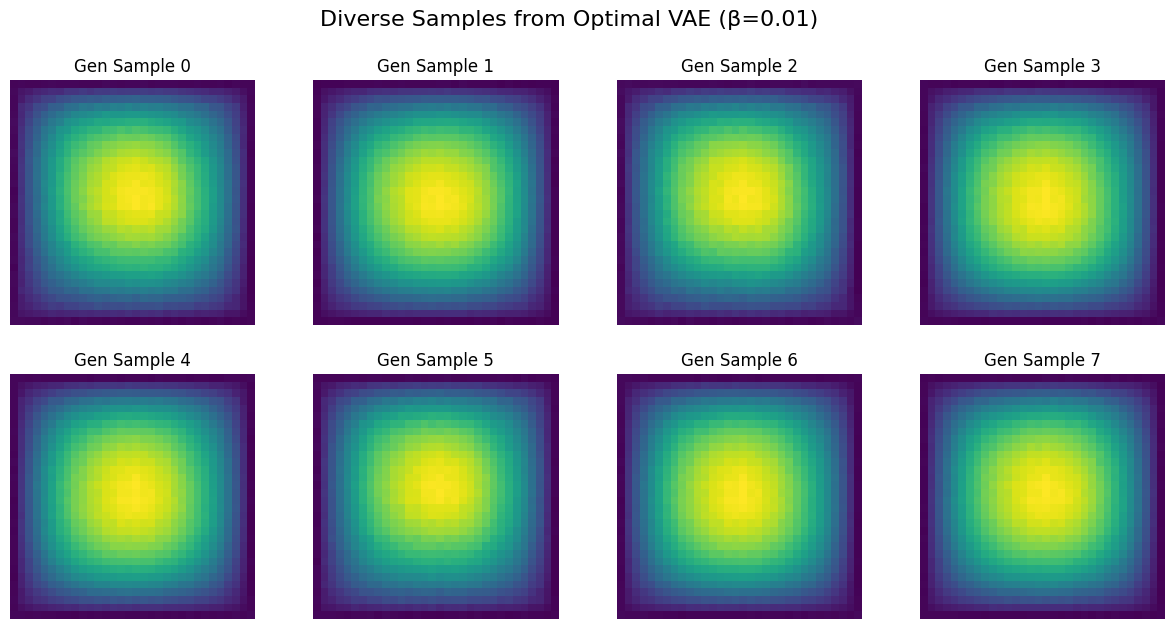

In [66]:
plt.figure(figsize=(12, 5))

# KDE Comparison
gen_opt_means = gen_samples_opt.mean(axis=(1, 2, 3))
sns.kdeplot(real_means, label='Ground Truth', color='black', lw=3)
sns.kdeplot(gen_opt_means, label=f'Optimal Candidate (β={optimal_beta})', color='darkorange', lw=2, linestyle='--')
plt.title("Distribution of Mean Pressure: Variance Recovery Validation")
plt.xlabel("Mean Pressure")
plt.legend()
plt.show()

# Grid of generated samples
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(gen_samples_opt[i, 0], origin='lower')
    ax.set_title(f"Gen Sample {i}")
    ax.axis('off')
plt.suptitle(f"Diverse Samples from Optimal VAE (β={optimal_beta})", fontsize=16)
plt.show()